# Rasch Model (1PL) — Bayesian Estimation with Stan

## 1. Model Description

The **Rasch model** (also called the **one-parameter logistic model, 1PL**) is the most parsimonious IRT model for dichotomously scored items (0 = incorrect, 1 = correct).

### Response Probability

$$P(X_{ji} = 1 \mid \theta_j, b_i) = \frac{\exp(\theta_j - b_i)}{1 + \exp(\theta_j - b_i)} = \text{logistic}(\theta_j - b_i)$$

| Parameter | Name | Interpretation |
|-----------|------|----------------|
| $\theta_j$ | Person ability | Latent trait of person $j$ |
| $b_i$ | Item difficulty | Value of $\theta$ where $P = 0.5$ |

### Key Properties
- **Equal discrimination**: All items have slope = 1 on the logit scale (no $a_i$ parameter).
- **Sufficient statistics**: The raw sum score $\sum_i X_{ji}$ is a sufficient statistic for $\theta_j$.
- **Specific objectivity**: Item comparisons do not depend on the ability distribution.

### Model Identification
The model is identified by fixing the ability distribution: $\theta_j \sim \mathcal{N}(0, 1)$.

### Bayesian Priors
$$\theta_j \sim \mathcal{N}(0, 1), \qquad b_i \sim \mathcal{N}(0, 2)$$

In [1]:
# Purpose: set up plotting style, fonts, and core dependencies for the notebook.
# Purpose: initialize reproducible randomness and load CmdStanPy directly.
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
import cmdstanpy
warnings.filterwarnings('ignore')

## 2. Synthetic Data Generation

We simulate responses from **77 students** on **20 items**.

- True person abilities: $\theta_j \sim \mathcal{N}(0, 1)$
- True item difficulties: $b_i \sim \mathcal{N}(0, 1)$ (centered)
- Responses: $X_{ji} \sim \text{Bernoulli}(\text{logistic}(\theta_j - b_i))$

In [2]:
# Purpose: generate synthetic Rasch-response data from known true parameters.
# Purpose: create person abilities, item difficulties, and binary item responses.
J, I = 177, 20  # persons, items

np.random.seed(5101) # reproducibility 위해 시드 고정 (5101로 설정)

theta_true = np.random.normal(0, 1, J)
b_true = np.random.normal(0, 1, I)
b_true -= b_true.mean()  # center for identifiability

logit_p = theta_true[:, None] - b_true[None, :]
p_true = 1.0 / (1.0 + np.exp(-logit_p))
Y = (np.random.uniform(size=(J, I)) < p_true).astype(int)

print(f"Response matrix shape : {Y.shape}")
print(f"Overall p(correct)    : {Y.mean():.3f}")
print(f"Person score range    : {Y.sum(axis=1).min()} – {Y.sum(axis=1).max()}")
print(f"Item difficulty range : [{b_true.min():.2f}, {b_true.max():.2f}]")

Response matrix shape : (177, 20)
Overall p(correct)    : 0.500
Person score range    : 1 – 19
Item difficulty range : [-1.55, 2.69]


## 3. Stan Model Code

The Stan model encodes the Rasch likelihood and Bayesian priors. Responses are stored in **long format** (one row per person-item observation).

In [3]:
# Purpose: define the Rasch model in Stan and compile it.
# Purpose: convert the response matrix into long-format data for CmdStan.
stan_code = """
data {
  int<lower=1> J;                        // number of persons
  int<lower=1> I;                        // number of items
  int<lower=0> N;                        // total observations
  array[N] int<lower=1,upper=J> jj;      // person indicator
  array[N] int<lower=1,upper=I> ii;      // item indicator
  array[N] int<lower=0,upper=1> y;       // binary responses
}
parameters {
  vector[J] theta;                       // person abilities
  vector[I] b;                           // item difficulties
}
model {
  theta ~ normal(0, 1);                  // ability prior (identifies scale)
  b     ~ normal(0, 2);                  // difficulty prior
  for (n in 1:N)
    y[n] ~ bernoulli_logit(theta[jj[n]] - b[ii[n]]);
}
"""

# Prepare long-format data
jj_arr, ii_arr, y_arr = [], [], []
for j in range(J):
    for i in range(I):
        jj_arr.append(j + 1)
        ii_arr.append(i + 1)
        y_arr.append(int(Y[j, i]))

stan_data = {'J': J, 'I': I, 'N': J * I,
             'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}

# Write and compile
tmpdir = tempfile.mkdtemp()
stan_path = os.path.join(tmpdir, 'rasch.stan')
with open(stan_path, 'w') as f:
    f.write(stan_code)

model = cmdstanpy.CmdStanModel(stan_file=stan_path)
print('Stan model compiled successfully.')

15:14:50 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\AppData\Local\Temp\tmp0yhxbhji\rasch.stan to exe file C:\Users\yongduek\AppData\Local\Temp\tmp0yhxbhji\rasch.exe
15:15:03 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\AppData\Local\Temp\tmp0yhxbhji\rasch.exe


Stan model compiled successfully.


## 4. MAP Estimation via optimize()

Before full MCMC sampling, we run CmdStan `optimize()` to obtain a **MAP estimate** (posterior mode under the specified priors).

- This is fast and useful for a baseline check.
- In CmdStanPy, `optimize()` does **not** return pure frequentist MLE for this Bayesian model; it returns MAP.

15:15:03 - cmdstanpy - INFO - Chain [1] start processing
15:15:03 - cmdstanpy - INFO - Chain [1] done processing


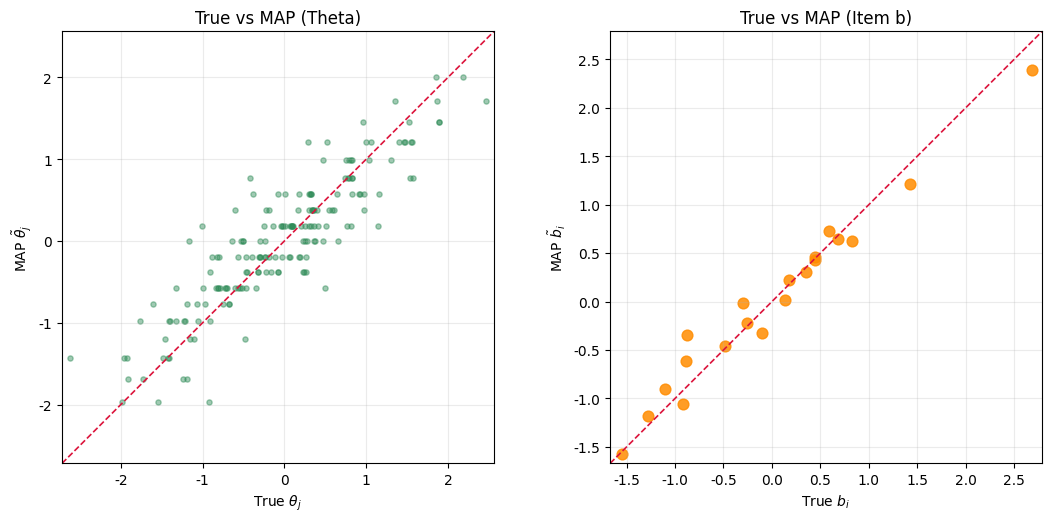

corr(theta_true, theta_map) = 0.890
corr(b_true,     b_map)     = 0.984


In [4]:
# Purpose: run MAP optimization as a fast point-estimation step before MCMC.
# Purpose: compare true parameters against MAP estimates on the logit scale.
map_fit = model.optimize(data=stan_data, seed=42)

# Extract MAP estimates
try:
    theta_map = np.asarray(map_fit.stan_variable('theta')).ravel()
    b_map = np.asarray(map_fit.stan_variable('b')).ravel()
except Exception:
    p = map_fit.optimized_params_dict
    theta_map = np.array([p[f'theta[{j}]'] for j in range(1, J + 1)])
    b_map = np.array([p[f'b[{i}]'] for i in range(1, I + 1)])

def _diag(ax, x, y, color='crimson'):
    lo = min(np.min(x), np.min(y)) - 0.1
    hi = max(np.max(x), np.max(y)) + 0.1
    ax.plot([lo, hi], [lo, hi], '--', color=color, lw=1.2)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))

axes[0].scatter(theta_true, theta_map, s=14, alpha=0.45, color='seagreen')
_diag(axes[0], theta_true, theta_map)
axes[0].set_title('True vs MAP (Theta)')
axes[0].set_xlabel('True $\\theta_j$')
axes[0].set_ylabel('MAP $\\tilde{\\theta}_j$')
axes[0].grid(alpha=0.25)

axes[1].scatter(b_true, b_map, s=60, alpha=0.85, color='darkorange')
_diag(axes[1], b_true, b_map)
axes[1].set_title('True vs MAP (Item b)')
axes[1].set_xlabel('True $b_i$')
axes[1].set_ylabel('MAP $\\tilde{b}_i$')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"corr(theta_true, theta_map) = {np.corrcoef(theta_true, theta_map)[0,1]:.3f}")
print(f"corr(b_true,     b_map)     = {np.corrcoef(b_true, b_map)[0,1]:.3f}")

## 5. Bayesian Inference via MCMC

We use **Hamiltonian Monte Carlo (HMC / NUTS)** via CmdStan. Four chains with 1000 warm-up and 1000 sampling iterations each.

In [5]:
# Purpose: run full Bayesian inference with NUTS/HMC sampling.
# Purpose: obtain posterior draws for person and item parameters.
fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True
)
print(fit.diagnose())

15:15:04 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

15:15:25 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [6]:
# Purpose: extract posterior samples and compute posterior-mean estimates.
# Purpose: summarize recovery of true parameters by Bayesian estimation.
# Extract posterior samples
theta_post = fit.stan_variable('theta')   # shape: (4000, J)
b_post     = fit.stan_variable('b')       # shape: (4000, I)

theta_est = theta_post.mean(axis=0)
b_est     = b_post.mean(axis=0)

print("Item difficulty recovery (true vs posterior mean):")
print(f"{'Item':>6} {'True b':>10} {'Est b':>10} {'Error':>10}")
for i in range(I):
    print(f"{i+1:>6} {b_true[i]:>10.3f} {b_est[i]:>10.3f} {b_est[i]-b_true[i]:>10.3f}")

corr_b = np.corrcoef(b_true, b_est)[0, 1]
corr_theta = np.corrcoef(theta_true, theta_est)[0, 1]
print(f"\nCorrelation (true vs estimated): b = {corr_b:.3f},  theta = {corr_theta:.3f}")

Item difficulty recovery (true vs posterior mean):
  Item     True b      Est b      Error
     1      1.420      1.271     -0.149
     2     -0.298     -0.005      0.293
     3      2.687      2.501     -0.186
     4      0.592      0.768      0.176
     5     -0.891     -0.641      0.249
     6     -1.104     -0.938      0.167
     7      0.449      0.482      0.033
     8     -0.257     -0.225      0.032
     9      0.680      0.680     -0.000
    10      0.440      0.454      0.014
    11     -0.106     -0.330     -0.224
    12     -0.880     -0.359      0.522
    13     -1.548     -1.635     -0.086
    14     -0.480     -0.469      0.011
    15      0.823      0.653     -0.170
    16      0.181      0.235      0.054
    17     -1.279     -1.230      0.050
    18      0.140      0.021     -0.119
    19      0.352      0.316     -0.036
    20     -0.917     -1.094     -0.176

Correlation (true vs estimated): b = 0.984,  theta = 0.890


## 5. Visualizations

### 5a. Wright Map (Person–Item Map)

A **Wright map** (also called a person–item map) displays **person ability estimates** and **item difficulty estimates** on the same logit scale.

- **Left panel**: Histogram of estimated person abilities $\hat{\theta}_j$. The distribution shape reveals whether the test is well-targeted for this group.
- **Right panel**: Item difficulties $\hat{b}_i$ as tick marks. Easy items are at the bottom (low $b$), hard items at the top (high $b$).

**Interpretation**: If the person distribution is centred around $b \approx 0$, the test is well-targeted. Items whose $b$ falls outside the bulk of the $\theta$ distribution provide little information for most students.

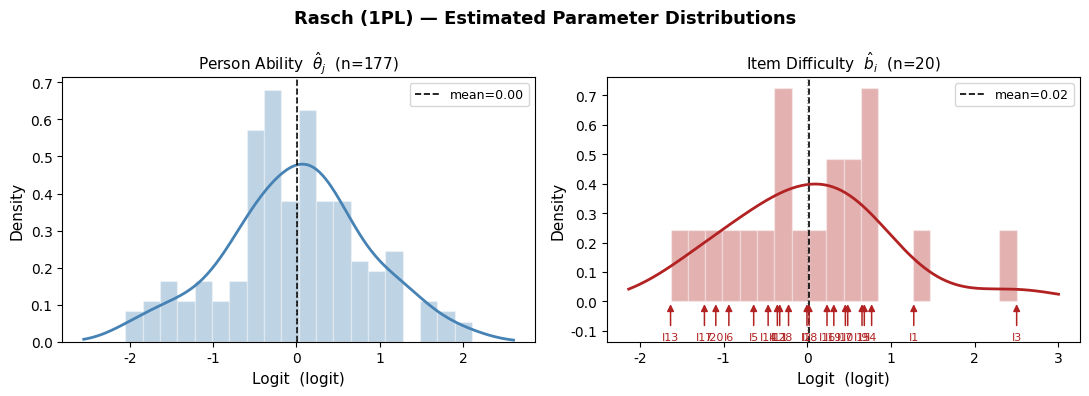

theta: mean=0.003  SD=0.850  range=[-2.05, 2.10]
b    : mean=0.023  SD=0.925  range=[-1.63, 2.50]


In [7]:
# Purpose: visualize posterior-mean distributions for person ability and item difficulty.
# Purpose: mark exact item locations with arrows on the item-density panel.
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Rasch (1PL) — Estimated Parameter Distributions', fontsize=13, fontweight='bold')

panels = [
    (axes[0], theta_est, r'Person Ability  $\hat{\theta}_j$',  'steelblue',  'logit'),
    (axes[1], b_est,     r'Item Difficulty  $\hat{b}_i$',       'firebrick',   'logit'),
]

for ax, vals, title, color, unit in panels:
    ax.hist(vals, bins=20, density=True, color=color, alpha=0.35, edgecolor='white')
    xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
    kde = gaussian_kde(vals, bw_method='scott')
    ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel(f'Logit  ({unit})', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

# Mark exact item locations on the right panel with arrows on the logit axis
ax_item = axes[1]
ymax = ax_item.get_ylim()[1]
for i, b in enumerate(b_est, start=1):
    ax_item.annotate('', xy=(b, 0), xytext=(b, -0.12 * ymax),
                     arrowprops=dict(arrowstyle='-|>', color='firebrick', lw=1.1),
                     annotation_clip=False)
    ax_item.text(b, -0.135 * ymax, f'I{i}', ha='center', va='top',
                 fontsize=8, color='firebrick', clip_on=False)
ax_item.set_ylim(-0.18 * ymax, ymax)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_rasch.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"theta: mean={theta_est.mean():.3f}  SD={theta_est.std():.3f}  "
      f"range=[{theta_est.min():.2f}, {theta_est.max():.2f}]")
print(f"b    : mean={b_est.mean():.3f}  SD={b_est.std():.3f}  "
      f"range=[{b_est.min():.2f}, {b_est.max():.2f}]")

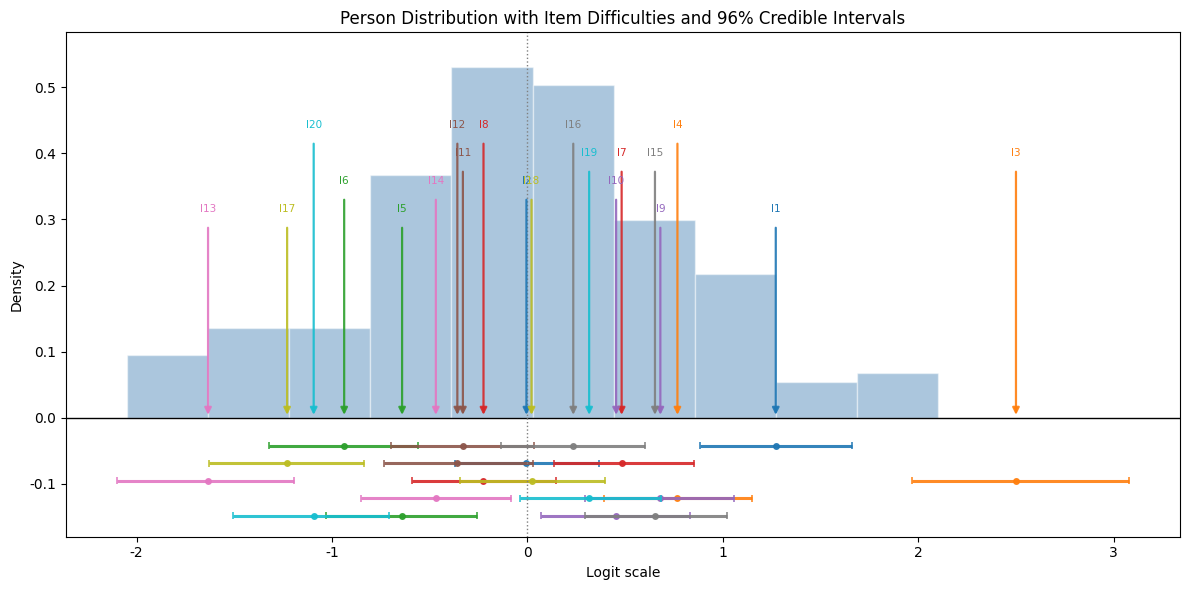

In [9]:
# Purpose: overlay person distribution with item locations and 96% credible intervals.
# Purpose: inspect item targeting and uncertainty on the shared logit scale.
# Person histogram on logit scale + item difficulty arrows + 96% credible intervals

theta_vals = theta_est if 'theta_est' in globals() else theta_true

if 'b_post' in globals():
    b_loc = b_post.mean(axis=0)
    b_ci_low, b_ci_high = np.quantile(b_post, [0.02, 0.98], axis=0)  # 96% CrI
else:
    b_loc = b_est if 'b_est' in globals() else b_true
    b_ci_low = b_loc - 0.2
    b_ci_high = b_loc + 0.2
    print("ℹ️ b_post not found: using placeholder intervals (±0.2).")

import matplotlib.cm as cm
item_colors = cm.tab10(np.linspace(0, 1, len(b_loc)))

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram of person abilities
counts, bins, _ = ax.hist(
    theta_vals,
    bins=10,
    density=True,
    color='steelblue',
    alpha=0.45,
    edgecolor='white',
    label='Persons (ability)'
)

ymax = max(counts) if len(counts) > 0 else 1.0

# Item difficulty arrows (vertical, pointing to x-axis)
for i, x in enumerate(b_loc):
    y_start = ymax * (0.55 + 0.08 * (i % 4))
    ax.annotate(
        '',
        xy=(x, 0.0),
        xytext=(x, y_start),
        arrowprops=dict(arrowstyle='-|>', color=item_colors[i], lw=1.6, alpha=0.9)
    )
    ax.text(x, y_start + ymax * 0.03, f'I{i+1}', ha='center', va='bottom',
            fontsize=7.5, color=item_colors[i])

# 96% credible intervals for item parameters (drawn below x-axis)
ci_levels = -ymax * (0.08 + 0.05 * (np.arange(len(b_loc)) % 5))
for i in range(len(b_loc)):
    y_ci = ci_levels[i]
    c = item_colors[i]
    ax.hlines(y_ci, b_ci_low[i], b_ci_high[i], color=c, lw=2.2, alpha=0.9)
    ax.vlines([b_ci_low[i], b_ci_high[i]], y_ci - ymax * 0.01, y_ci + ymax * 0.01,
              color=c, lw=1.2, alpha=0.9)
    ax.plot(b_loc[i], y_ci, 'o', color=c, markersize=4, alpha=0.9)

ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='gray', linestyle=':', lw=1)

ax.set_xlabel('Logit scale')
ax.set_ylabel('Density')
ax.set_title('Person Distribution with Item Difficulties and 96% Credible Intervals')
ax.set_ylim(ci_levels.min() - ymax * 0.06, ymax * 1.1)

plt.tight_layout()
plt.show()

### 5b. Item Difficulty distributions


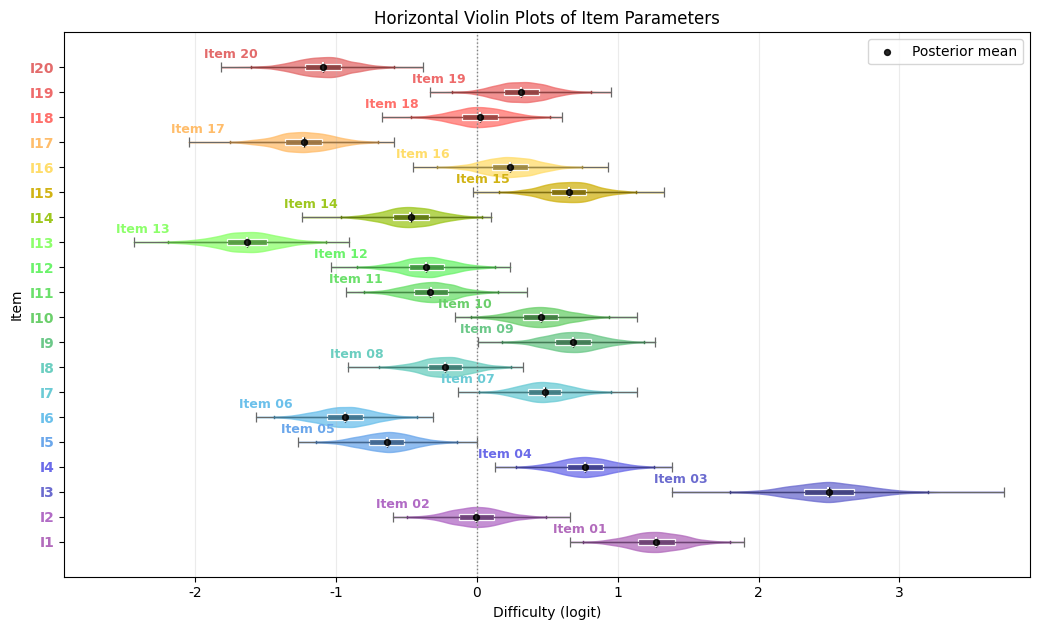

In [34]:
# Purpose: show horizontal violin plots for item difficulty posteriors.
# Purpose: assign a distinct color to each item violin and its matching item label.
# Horizontal violin plots for item difficulty parameters

if 'b_post' in globals():
    item_samples = b_post  # (draws, I)
elif 'fit' in globals():
    item_samples = fit.stan_variable('b')
else:
    center = b_est if 'b_est' in globals() else b_true
    item_samples = np.random.normal(loc=center, scale=0.15, size=(2000, len(center)))
    print("ℹ️ b_post not found: using proxy draws around b_est/b_true.")

n_items = item_samples.shape[1]
positions = np.arange(1, n_items + 1)
base_colors = plt.cm.nipy_spectral(np.linspace(0.06, 0.94, n_items))
plot_colors = 0.58 * base_colors[:, :3] + 0.42 * np.ones((n_items, 3))

# Manually deepen low-contrast yellow tones for Item 14 and Item 15.
if n_items >= 15:
    plot_colors[13] = np.array([0.62, 0.78, 0.12])
    plot_colors[14] = np.array([0.82, 0.70, 0.08])

dark_box_colors = np.clip(0.62 * plot_colors, 0, 1)

fig, ax = plt.subplots(figsize=(10.5, 6.4))

vp = ax.violinplot(
    [item_samples[:, i] for i in range(n_items)],
    positions=positions,
    vert=False,
    widths=0.8,
    showmeans=True,
    showmedians=True,
    showextrema=True
)

for i, body in enumerate(vp['bodies']):
    body.set_facecolor(plot_colors[i])
    body.set_edgecolor(plot_colors[i])
    body.set_alpha(0.75)
    body.set_linewidth(1.0)

# Add compact horizontal boxplots inside each violin using darker matching colors.
bp = ax.boxplot(
    [item_samples[:, i] for i in range(n_items)],
    positions=positions,
    vert=False,
    widths=0.22,
    patch_artist=True,
    showfliers=False,
    manage_ticks=False,
    zorder=3
)

for i, box in enumerate(bp['boxes']):
    box.set_facecolor(dark_box_colors[i])
    box.set_alpha(0.95)
    box.set_edgecolor('white')
    box.set_linewidth(0.9)

for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(1.4)

for i, whisker in enumerate(bp['whiskers']):
    whisker.set_color(dark_box_colors[i // 2])
    whisker.set_linewidth(1.0)

for i, cap in enumerate(bp['caps']):
    cap.set_color(dark_box_colors[i // 2])
    cap.set_linewidth(1.0)

vp['cmeans'].set_color('black')
vp['cmeans'].set_linewidth(1.0)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(1.4)
vp['cbars'].set_color('dimgray')
vp['cbars'].set_linewidth(0.9)
vp['cmins'].set_color('dimgray')
vp['cmins'].set_linewidth(0.9)
vp['cmaxes'].set_color('dimgray')
vp['cmaxes'].set_linewidth(0.9)

x_min = np.min(item_samples)
x_max = np.max(item_samples)
x_pad = 0.08 * (x_max - x_min + 1e-9)

for i, y0 in enumerate(positions, start=1):
    x_left = np.min(item_samples[:, i - 1])
    ax.text(
        x_left - 0.25 * x_pad,
        y0 + 0.24,
        f'Item {i:02d}',
        ha='left',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=plot_colors[i - 1]
    )

ax.set_xlim(x_min - x_pad, x_max + 0.03 * (x_max - x_min + 1e-9))

if 'b_est' in globals() and len(b_est) == n_items:
    ax.scatter(b_est, positions, color='black', s=18, alpha=0.85, label='Posterior mean', zorder=4)

ax.set_yticks(positions)
ax.set_yticklabels([f'I{i}' for i in positions])
for tick_label, color in zip(ax.get_yticklabels(), plot_colors):
    tick_label.set_color(color)
    tick_label.set_fontweight('bold')

ax.set_xlabel('Difficulty (logit)')
ax.set_ylabel('Item')
ax.set_title('Horizontal Violin Plots of Item Parameters')
ax.axvline(0, color='gray', linestyle=':', linewidth=1)
ax.grid(axis='x', alpha=0.25)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

### 5c. True Item parameters and Posterior Distributions

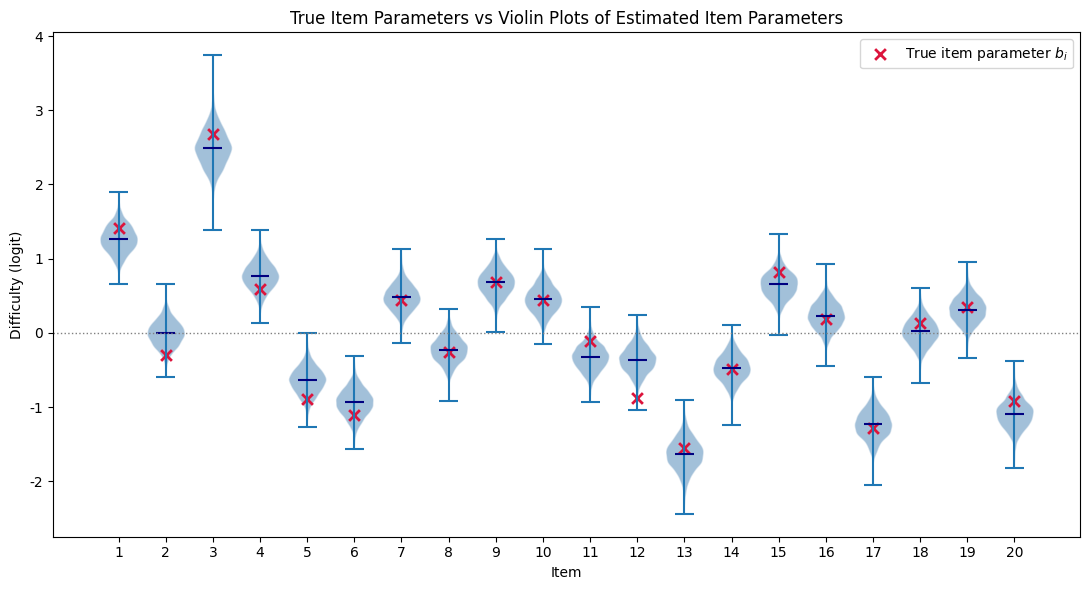

In [35]:
# Purpose: compare true item parameters with posterior item distributions.
# Purpose: visualize recovery quality using violin plots for each item.
# True item parameters vs posterior violin plots

if 'b_post' in globals():
    item_samples = b_post  # shape: (draws, I)
elif 'fit' in globals():
    item_samples = fit.stan_variable('b')
else:
    print("ℹ️ b_post not found: Cannot proceed with violin plots.")
    item_samples = None

n_items = len(b_true)
positions = np.arange(1, n_items + 1)

fig, ax = plt.subplots(figsize=(11, 6))

vp = ax.violinplot(
    [item_samples[:, i] for i in range(n_items)],
    positions=positions,
    showmeans=False,
    showmedians=True,
    widths=0.8
)

for body in vp['bodies']:
    body.set_facecolor('steelblue')
    body.set_edgecolor('white')
    body.set_alpha(0.5)

vp['cmedians'].set_color('navy')
vp['cmedians'].set_linewidth(1.5)

ax.scatter(
    positions, b_true,
    color='crimson', marker='x', s=60, linewidths=2,
    label='True item parameter $b_i$'
)

ax.set_xticks(positions)
ax.set_xlabel('Item')
ax.set_ylabel('Difficulty (logit)')
ax.set_title('True Item Parameters vs Violin Plots of Estimated Item Parameters')
ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

### 5d. True vs Posterior Person Parameter Distribution

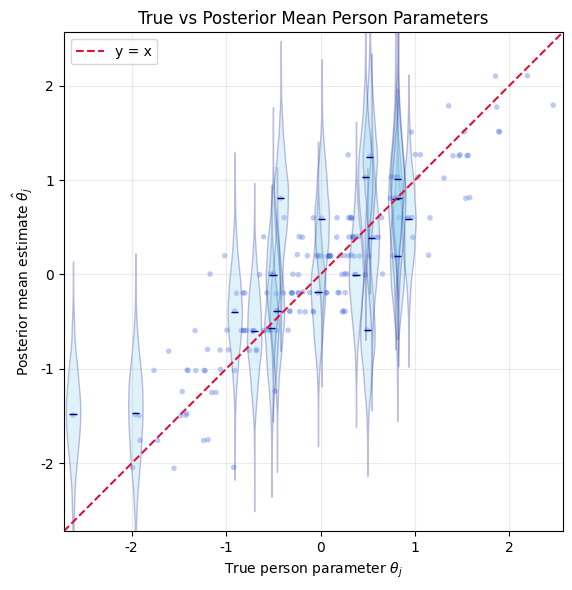

In [36]:
# Purpose: compare true person parameters with posterior mean estimates.
# Purpose: add posterior-violin overlays to inspect uncertainty and recovery.
# True person parameters vs posterior mean estimates (with diagonal + posterior violins)

if 'theta_true' not in globals() or 'theta_est' not in globals():
    raise ValueError("theta_true and/or theta_est not found in notebook variables.")

# Get posterior draws if needed
if 'theta_post' not in globals() and 'fit' in globals():
    theta_post = fit.stan_variable('theta')  # shape: (draws, J)

fig, ax = plt.subplots(figsize=(6, 6))

# Scatter: true vs posterior mean
ax.scatter(theta_true, theta_est, s=16, alpha=0.35, color='royalblue', edgecolor='none')

# Optional violin plots for posterior distributions (subset for readability)
if 'theta_post' in globals() and theta_post.shape[1] == len(theta_true):
    max_violin = 20
    idx = np.linspace(0, len(theta_true) - 1, max_violin, dtype=int)
    pos = theta_true[idx]
    samples = [theta_post[:, i] for i in idx]

    width = 0.03 * (theta_true.max() - theta_true.min() + 1e-9)
    vp = ax.violinplot(
        samples,
        positions=pos,
        widths=width,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )
    for body in vp['bodies']:
        body.set_facecolor('skyblue')
        body.set_edgecolor('navy')
        body.set_alpha(0.25)
    vp['cmedians'].set_color('navy')
    vp['cmedians'].set_linewidth(1.0)
else:
    print("ℹ️ theta_post not found: violin plots skipped.")

# Diagonal reference line
lo = min(theta_true.min(), theta_est.min()) - 0.1
hi = max(theta_true.max(), theta_est.max()) + 0.1
ax.plot([lo, hi], [lo, hi], '--', color='crimson', linewidth=1.5, label='y = x')

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('True person parameter $\\theta_j$')
ax.set_ylabel('Posterior mean estimate $\\hat{\\theta}_j$')
ax.set_title('True vs Posterior Mean Person Parameters')
ax.grid(alpha=0.25)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

---
## Statistical Analyses
---

## 6. Analysis with MLE/MAP Point Estimate (점추정)



## 6. MAP 추정치 해석 및 활용 가이드 (MAP Estimate Interpretation Guide)

이 섹션은 Rasch 모형에서 얻은 MAP 추정치(MAP estimates)를 **어떻게 해석(interpretation)**하고 **어떤 분석/추론(inference)**에 활용할 수 있는지 교육 목적에 맞게 정리한 것입니다.

구성은 다음과 같습니다.
1. 척도 해석(logit scale interpretation)
2. 확률 변환(probability transformation)
3. 순위화/비교(ranking & comparison)
4. 타게팅 분석(test targeting)
5. 적합도 점검의 출발점(model-fit screening)
6. 의사결정 활용(decision support)
7. 주의사항(caveats)

아래 셀부터 각 주제를 개별적으로 자세히 설명합니다.

### 6-1. 공통 척도 해석 (Common Logit Scale Interpretation)

Rasch 모형의 핵심은 사람능력(person ability, $\\theta_j$)과 문항난이도(item difficulty, $b_i$)가 **동일한 로짓 척도(common logit scale)** 위에 놓인다는 점입니다.

- $\theta_j$가 클수록 능력이 높습니다.
- $b_i$가 클수록 문항이 어렵습니다.
- 두 값의 차이(difference) 즉 $\theta_j - b_i$가 정답확률을 직접 결정합니다.

정답확률(response probability)은 다음과 같습니다.

$$
    P(X_{ji}=1) = \operatorname{logit}^{-1}(\theta_j - b_i)
$$

즉,
- $\theta_j = b_i$이면 정답확률은 0.5
- $\theta_j > b_i$이면 정답확률은 0.5보다 큼
- $\theta_j < b_i$이면 정답확률은 0.5보다 작음

해석 포인트:
- 절대값 자체보다도 **상대적 위치(relative location)**와 **차이(gap)**가 중요합니다.

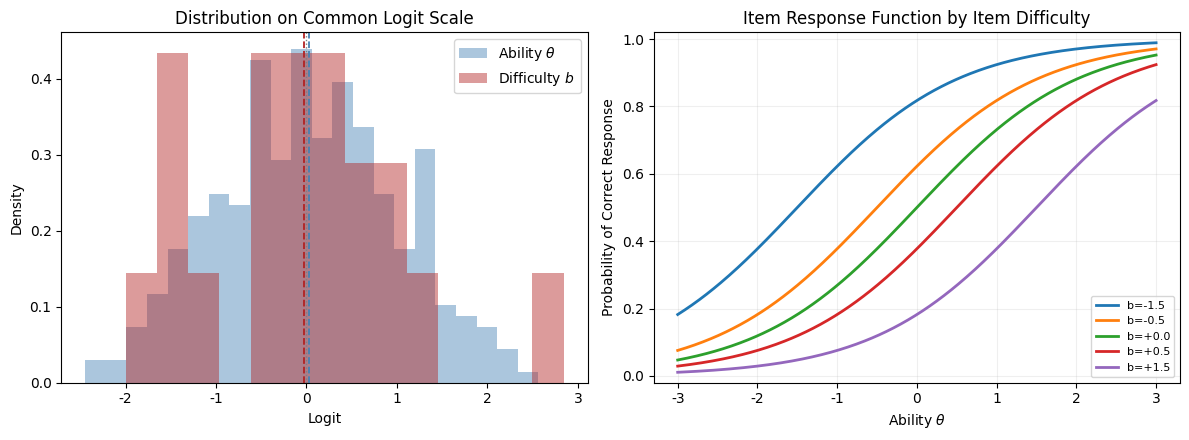

[해석] Rasch 모형에서 능력(θ)과 난이도(b)는 동일 로짓 척도에 위치하며, 해석의 핵심은 절대값보다 차이(θ-b)이다.
[해석] 동일한 θ에서도 b가 증가하면 정답확률 곡선이 우측으로 이동하므로 문항은 더 어려워진다.


In [37]:
# [6-1 Simulation] 공통 로짓 척도(Common Logit Scale)에서 능력과 난이도의 상대적 위치를 시각화한다.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(6101)
J_sim, I_sim = 300, 20
theta_sim = rng.normal(0.0, 1.0, J_sim)
b_sim = rng.normal(0.0, 1.0, I_sim)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(theta_sim, bins=22, alpha=0.45, density=True, color='steelblue', label='Ability $\\theta$')
axes[0].hist(b_sim, bins=14, alpha=0.45, density=True, color='firebrick', label='Difficulty $b$')
axes[0].axvline(theta_sim.mean(), color='steelblue', linestyle='--', lw=1.3)
axes[0].axvline(b_sim.mean(), color='firebrick', linestyle='--', lw=1.3)
axes[0].axvline(0, color='gray', linestyle=':', lw=1)
axes[0].set_title('Distribution on Common Logit Scale')
axes[0].set_xlabel('Logit')
axes[0].set_ylabel('Density')
axes[0].legend(loc='best')

# $P(X=1)=logit^{-1}(theta-b)$의 단조성(monotonicity) 시연
x = np.linspace(-3, 3, 400)
for d in [-1.5, -0.5, 0.0, 0.5, 1.5]:
    p = 1 / (1 + np.exp(-(x - d)))
    axes[1].plot(x, p, lw=2, label=f'b={d:+.1f}')
axes[1].set_title('Item Response Function by Item Difficulty')
axes[1].set_xlabel('Ability $\\theta$')
axes[1].set_ylabel('Probability of Correct Response')
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print('[해석] Rasch 모형에서 능력(θ)과 난이도(b)는 동일 로짓 척도에 위치하며, 해석의 핵심은 절대값보다 차이(θ-b)이다.')
print('[해석] 동일한 θ에서도 b가 증가하면 정답확률 곡선이 우측으로 이동하므로 문항은 더 어려워진다.')

### 6-2. 확률로 변환하여 읽기 (Probability Transformation)

MAP/MLE 점추정(point estimate)만 있어도 교육적으로 매우 직관적인 해석이 가능합니다.

예시:
- 특정 학습자 $j$와 문항 $i$에 대해
  $$
  \hat p_{ji} = \operatorname{logit}^{-1}(\hat\theta_j - \hat b_i)
  $$
  를 계산하면, 해당 학습자가 해당 문항을 맞출 **예상 정답확률(expected probability)**을 얻습니다.

활용:
- 학습자별 약점 문항 탐색(weak-item identification)
- 문항별 도달가능 집단 파악(accessibility by ability band)
- 기대 총점(expected total score) 계산

주의:
- 이는 MAP 기반 예측(prediction)이며, 불확실성(uncertainty)을 충분히 반영하려면 posterior interval과 함께 보는 것이 바람직합니다.

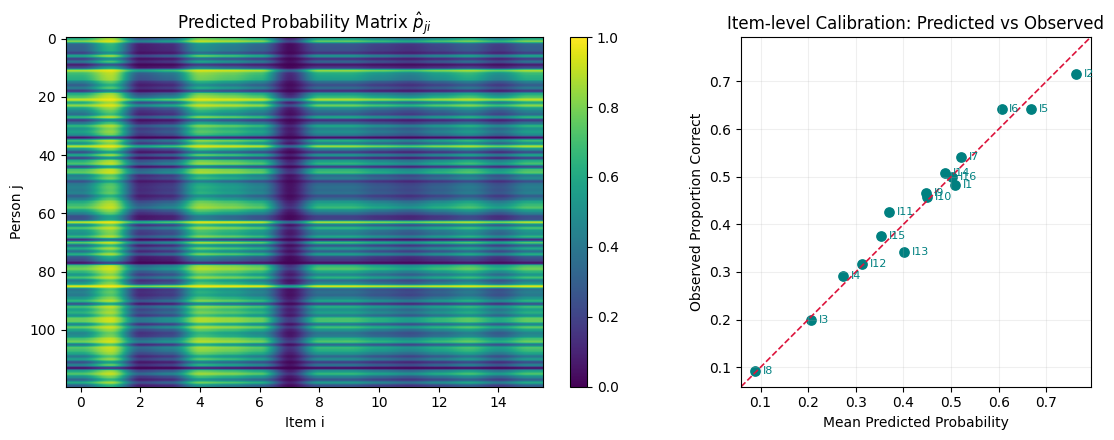

[해석] 문항 수준 예측-관측 정합성(calibration)의 RMSE = 0.0290
[해석] MAP 점추정은 학습자×문항 단위의 기대 정답확률을 제공하며, 교육적 의사결정의 정량적 근거로 사용될 수 있다.


In [40]:
# [6-2 Simulation] MAP 점추정치를 확률로 변환하여 예측 행렬(prediction matrix)과 관측 반응을 비교한다.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(6102)
J_sim, I_sim = 120, 16
theta_sim = rng.normal(0, 1, J_sim)
b_sim = rng.normal(0, 1, I_sim)

eta = theta_sim[:, None] - b_sim[None, :]
p_hat = 1 / (1 + np.exp(-eta))
y_obs = rng.binomial(1, p_hat)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im = axes[0].imshow(p_hat, aspect='auto', cmap='viridis', vmin=0, vmax=1)
axes[0].set_title('Predicted Probability Matrix $\\hat{p}_{ji}$')
axes[0].set_xlabel('Item i')
axes[0].set_ylabel('Person j')
plt.colorbar(im, ax=axes[0], fraction=0.046)

pred_item_mean = p_hat.mean(axis=0)
obs_item_mean = y_obs.mean(axis=0)
axes[1].scatter(pred_item_mean, obs_item_mean, color='teal', s=45)
lo = min(pred_item_mean.min(), obs_item_mean.min()) - 0.03
hi = max(pred_item_mean.max(), obs_item_mean.max()) + 0.03
axes[1].plot([lo, hi], [lo, hi], '--', color='crimson', lw=1.2)
axes[1].set_xlim(lo, hi)
axes[1].set_ylim(lo, hi)
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_title('Item-level Calibration: Predicted vs Observed')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Observed Proportion Correct')
axes[1].grid(alpha=0.2)

dx = 0.022 * (hi - lo)
for i, (xv, yv) in enumerate(zip(pred_item_mean, obs_item_mean), start=1):
    axes[1].text(
        xv + dx, yv, f'I{i}',
        fontsize=8, color='teal',
        va='center', ha='left'
    )

plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((pred_item_mean - obs_item_mean) ** 2))
print(f'[해석] 문항 수준 예측-관측 정합성(calibration)의 RMSE = {rmse:.4f}')
print('[해석] MAP 점추정은 학습자×문항 단위의 기대 정답확률을 제공하며, 교육적 의사결정의 정량적 근거로 사용될 수 있다.')

### 6-3. 순위화 및 비교 (Ranking and Pairwise Comparison)

MAP/MLE 추정치는 순위화(ranking)에 매우 유용합니다.

- 사람 순위(person ranking): $\hat\theta_j$ 내림차순
- 문항 난이도 순위(item difficulty ranking): $\hat b_i$ 오름차순(쉬운 문항) 또는 내림차순(어려운 문항)

또한 쌍비교(pairwise comparison)가 가능합니다.

- 문항 비교: $\hat b_{i_2} - \hat b_{i_1}$
  - 양수면 $i_2$가 더 어려움
- 학습자 비교: $\hat\theta_{j_2} - \hat\theta_{j_1}$
  - 양수면 $j_2$가 더 높은 능력

실무 팁:
- 작은 차이는 실제적으로 유의미하지 않을 수 있으므로 practical threshold(실질 임계값)를 정해 해석하는 것이 좋습니다.

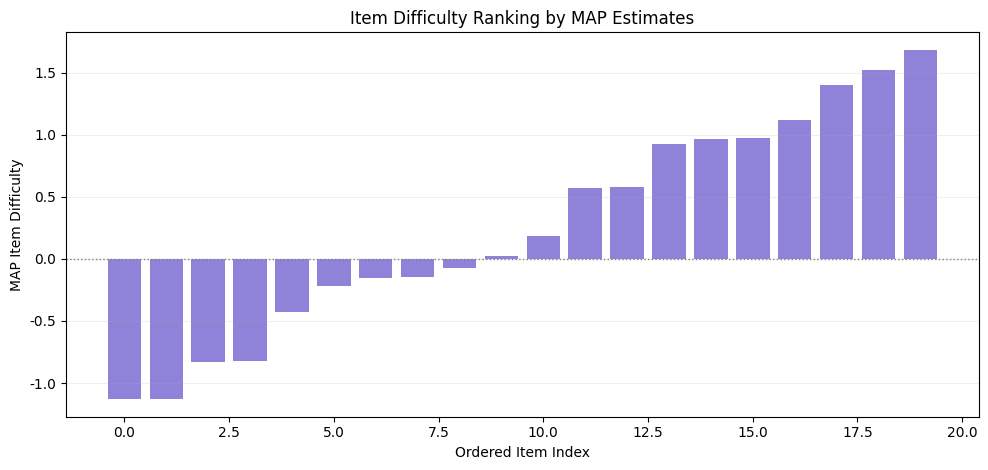

[해석] 난이도 순위는 b_MAP의 상대적 크기에 의해 결정되며, 값 차이는 문항 간 상대적 난이도 격차를 의미한다.
가장 어려운 5개 문항 인덱스(0-based): [19 18 17 16 15]
가장 쉬운 5개 문항 인덱스(0-based): [0 1 2 3 4]
쌍비교: hardest(19) - easiest(0) = 2.814 logits
[해석] 본 차이가 클수록 두 문항의 수행 요구수준(performance demand) 차이가 크다.


In [41]:
# [6-3 Simulation] MAP 추정치 기반 순위화(ranking)와 쌍비교(pairwise comparison)를 수행한다.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(6103)
J_sim, I_sim = 80, 20
theta_map_sim = np.sort(rng.normal(0, 0.95, J_sim))
b_map_sim = np.sort(rng.normal(0, 0.9, I_sim))

hardest_idx = np.argsort(b_map_sim)[-5:][::-1]
easiest_idx = np.argsort(b_map_sim)[:5]

fig, ax = plt.subplots(figsize=(10, 4.8))
bar_x = np.arange(I_sim)
ax.bar(bar_x, b_map_sim, color='slateblue', alpha=0.75)
ax.axhline(0, color='gray', linestyle=':', lw=1)
ax.set_title('Item Difficulty Ranking by MAP Estimates')
ax.set_xlabel('Ordered Item Index')
ax.set_ylabel('MAP Item Difficulty')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

print('[해석] 난이도 순위는 b_MAP의 상대적 크기에 의해 결정되며, 값 차이는 문항 간 상대적 난이도 격차를 의미한다.')
print('가장 어려운 5개 문항 인덱스(0-based):', hardest_idx)
print('가장 쉬운 5개 문항 인덱스(0-based):', easiest_idx)

# 쌍비교 예시
i1, i2 = hardest_idx[0], easiest_idx[0]
delta_b = b_map_sim[i1] - b_map_sim[i2]
print(f'쌍비교: hardest({i1}) - easiest({i2}) = {delta_b:.3f} logits')
print('[해석] 본 차이가 클수록 두 문항의 수행 요구수준(performance demand) 차이가 크다.')

### 6-4. 검사 타게팅 분석 (Test Targeting Analysis)

MAP/MLE 추정치는 검사 문항이 학습자 집단에 맞는지( targeting )를 판단하는 데 핵심 자료가 됩니다.

핵심 아이디어:
- 사람 분포(person distribution): $\hat\theta$ 분포
- 문항 분포(item distribution): $\hat b$ 분포
- 두 분포가 잘 겹치면 검사 타게팅이 양호(good targeting)합니다.

해석 예:
- 문항들이 전반적으로 $b$가 너무 크면: 현재 집단에게 어려운 시험
- 문항들이 전반적으로 $b$가 너무 작으면: 현재 집단에게 쉬운 시험
- 특정 구간에 문항이 비면: 측정 공백(measurement gap)

실무적으로는 Wright map(person-item map)에서 가장 직관적으로 확인할 수 있습니다.

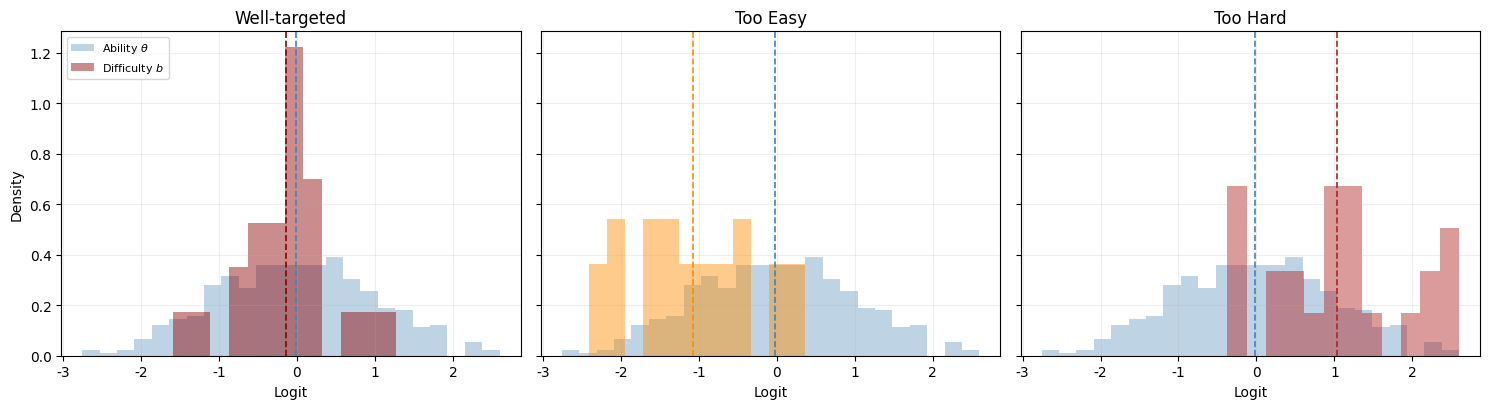

Well-targeted gap(mean(theta)-mean(b)) = +0.119
Too Easy gap(mean(theta)-mean(b))      = +1.054
Too Hard gap(mean(theta)-mean(b))      = -1.051
[해석] gap이 0에 가까울수록 집단-문항 정렬(alignment)이 양호하며, 절대값이 커질수록 타게팅 편향(mistargeting)이 증가한다.


In [43]:
# [6-4 Simulation] 검사 타게팅(test targeting) 적합성을 능력-난이도 분포 중첩으로 진단한다.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(6104)
J = 400
theta_pop = rng.normal(0, 1, J)

# 세 가지 테스트 시나리오: 적정/과도하게 쉬움/과도하게 어려움
b_good = rng.normal(0.0, 0.9, 24)
b_easy = rng.normal(-1.2, 0.9, 24)
b_hard = rng.normal(1.2, 0.9, 24)

cases = [
    ('Well-targeted', b_good, 'darkred'),
    ('Too Easy', b_easy, 'darkorange'),
    ('Too Hard', b_hard, 'firebrick'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (name, b_case, color) in zip(axes, cases):
    ax.hist(theta_pop, bins=24, density=True, alpha=0.35, color='steelblue', label='Ability $\\theta$')
    ax.hist(b_case, bins=12, density=True, alpha=0.45, color=color, label='Difficulty $b$')
    ax.axvline(theta_pop.mean(), color='steelblue', linestyle='--', lw=1.2)
    ax.axvline(b_case.mean(), color=color, linestyle='--', lw=1.2)
    ax.set_title(name)
    ax.set_xlabel('Logit')
    ax.grid(alpha=0.2)

axes[0].set_ylabel('Density')
axes[0].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

def targeting_gap(theta, b):
    return float(np.mean(theta) - np.mean(b))

print(f"Well-targeted gap(mean(theta)-mean(b)) = {targeting_gap(theta_pop, b_good):+.3f}")
print(f"Too Easy gap(mean(theta)-mean(b))      = {targeting_gap(theta_pop, b_easy):+.3f}")
print(f"Too Hard gap(mean(theta)-mean(b))      = {targeting_gap(theta_pop, b_hard):+.3f}")
print('[해석] gap이 0에 가까울수록 집단-문항 정렬(alignment)이 양호하며, 절대값이 커질수록 타게팅 편향(mistargeting)이 증가한다.')

### 6-5. 적합도 점검의 목적 (Why Model-Fit Screening?)

이 섹션의 핵심 목적은 **"추정은 했는데, 이 Rasch 모형이 데이터를 얼마나 그럴듯하게 설명하는가?"**를 확인하는 것입니다.

쉽게 말하면:
- MAP 추정치로 계산한 예측값(prediction)과
- 실제 응답(observed response)
이 얼마나 잘 맞는지 보는 과정입니다.

무엇을 하려는가?
1. **모형 타당성 확인(model adequacy check)**
- 추정된 $\hat\theta, \hat b$가 실제 반응 패턴을 설명하는지 확인

2. **문제 지점 찾기(diagnostic screening)**
- 특정 문항(item)이나 특정 사람(person)에서 예측오차가 큰지 탐색
- 예: 쉬워야 할 문항인데 고능력자도 반복적으로 틀리는 패턴

3. **다음 분석 방향 결정(decision for next step)**
- 단순 Rasch로 충분한지
- 혹은 DIF 분석, 다차원 모형, 문항 수정이 필요한지 판단

왜 필요한가?
- 파라미터가 예쁘게 추정되어도, 실제 데이터와 안 맞으면 해석 신뢰도가 낮아집니다.
- 즉, **적합도 점검은 "해석 전에 신뢰성 검문"** 단계입니다.

MAP 기반 점검은 어디까지?
- 빠른 1차 점검(quick screening)에 매우 유용
- 최종 결론에는 posterior predictive check(PPC), 잔차분석(residual analysis), 항목적합도 지표(item fit index)까지 함께 보는 것이 권장됩니다.

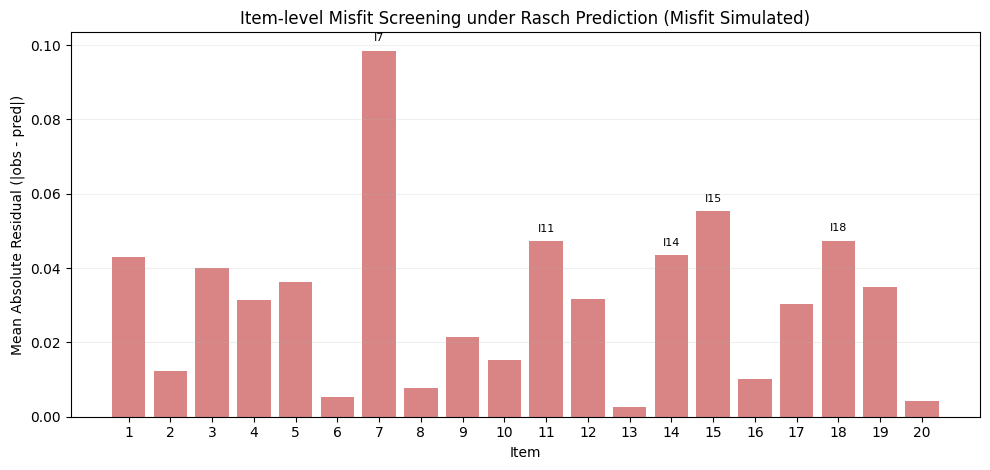

[해석] 적합도 점검의 목적은 모형이 설명하지 못하는 체계적 오차를 조기에 식별하는 것이다.
잔차 기준 상위 의심 문항(1-based): [7, 15, 18, 11, 14]
[해석] 본 예시에서는 의도적으로 변별력을 교란한 문항이 상위에 나타나며, 이는 확장모형 검토의 근거가 된다.


In [46]:
# [6-5 Simulation] 적합도 점검(model-fit screening): 예측-관측 오차의 문항 패턴을 진단한다.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(6105)
J, I = 300, 20
theta = rng.normal(0, 1, J)
b = rng.normal(0, 1, I)

# Rasch 기반 예측확률
p_rasch = 1 / (1 + np.exp(-(theta[:, None] - b[None, :])))

# 의도적 미적합(misfit) 유도: 문항 7은 낮은 변별력, 문항 15는 높은 변별력
a = np.ones(I)
a[6] = 0.45
a[14] = 1.8
p_misfit = 1 / (1 + np.exp(-(a[None, :] * (theta[:, None] - b[None, :]))))

# 관측 데이터는 misfit 생성 메커니즘에서 발생했다고 가정
Y_obs = rng.binomial(1, p_misfit) # 관측값은 0 또는 1의 이항형태로 생성

# Rasch 예측 대비 잔차 기반 문항 진단
item_resid = (Y_obs - p_rasch).mean(axis=0)
item_abs_resid = np.abs(item_resid)
flag_idx = np.argsort(item_abs_resid)[-5:][::-1]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(np.arange(1, I + 1), item_abs_resid, color='indianred', alpha=0.75)
ax.set_xlabel('Item')
ax.set_xticks(np.arange(1, I + 1))
ax.set_ylabel('Mean Absolute Residual (|obs - pred|)')
ax.set_title('Item-level Misfit Screening under Rasch Prediction (Misfit Simulated)')
ax.grid(axis='y', alpha=0.2)
for k in flag_idx:
    ax.text(k + 1, item_abs_resid[k] + 0.002, f'I{k+1}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print('[해석] 적합도 점검의 목적은 모형이 설명하지 못하는 체계적 오차를 조기에 식별하는 것이다.')
print('잔차 기준 상위 의심 문항(1-based):', [int(i + 1) for i in flag_idx])
print('[해석] 본 예시에서는 의도적으로 변별력을 교란한 문항이 상위에 나타나며, 이는 확장모형 검토의 근거가 된다.')

### 6-6. 의사결정 활용 (Decision Support)

MAP 추정치 기반으로 다음과 같은 교육적 의사결정을 지원할 수 있습니다.

- 성취수준 구간화(ability banding): $\hat\theta$ 구간에 따른 지원전략 설계
- 문항 은행 운영(item bank management): 난이도 분포 균형화
- 맞춤형 추천(adaptive recommendation): 현재 능력 근처 난이도 문항 제시
- 성취기준 연계(standard setting support): 절단점(cut score) 주변 문항 점검

중요:
- 고위험 결정(high-stakes decision)에는 반드시 불확실성(uncertainty) 정보(credible interval 등)를 함께 고려해야 합니다.

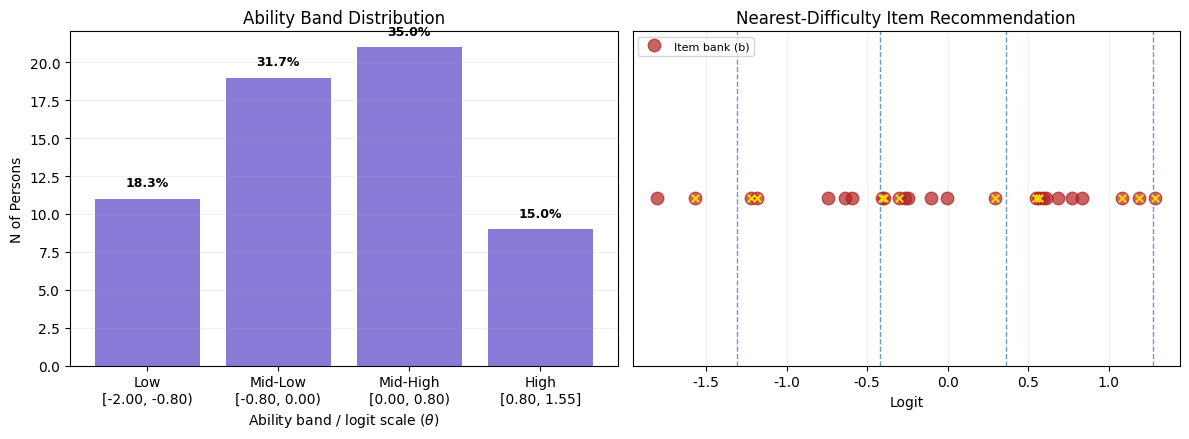

[해석] MAP 기반 능력 구간화는 지원전략(보충/심화) 설계에 직접 연결될 수 있다.
[해석] 또한 |theta-b| 최소 기준의 문항 추천은 적응형 학습(adaptive support)의 기초 규칙으로 활용 가능하다.


In [68]:
# [6-6 Simulation] MAP 추정치 기반 의사결정(decision support): 능력 구간화와 문항 추천 예시.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(6106)
J, I = 60, 25
theta_map = np.sort(rng.normal(0, 0.9, J))
b_bank = np.sort(rng.normal(0, 1.0, I))

# 능력 구간화(ability banding)
bands = np.digitize(theta_map, bins=[-0.8, 0.0, 0.8])
band_labels = np.array(['Low', 'Mid-Low', 'Mid-High', 'High'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
counts = np.bincount(bands, minlength=4)
axes[0].bar(np.arange(4), counts, color='slateblue', alpha=0.8)
total = counts.sum()
for i, c in enumerate(counts):
    axes[0].text(
        i, c + max(counts) * 0.03,
        f'{c / total:.1%}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[0].set_xticks(np.arange(4))
axes[0].set_xticklabels(band_labels)
axes[0].set_title('Ability Band Distribution')
axes[0].set_ylabel('N of Persons')
axes[0].grid(axis='y', alpha=0.2)
theta_edges = np.array([theta_map.min(), -0.8, 0.0, 0.8, theta_map.max()])
theta_ticklabels = [
    f'{band_labels[0]}\n[{theta_edges[0]:.2f}, -0.80)',
    f'{band_labels[1]}\n[-0.80, 0.00)',
    f'{band_labels[2]}\n[0.00, 0.80)',
    f'{band_labels[3]}\n[0.80, {theta_edges[4]:.2f}]'
]
axes[0].set_xticklabels(theta_ticklabels)
axes[0].set_xlabel(r'Ability band / logit scale ($\theta$)')

# 대표 학습자 4명에 대해 근접 난이도 문항 추천
rep_idx = [5, 20, 40, 55]
axes[1].plot(b_bank, np.zeros_like(b_bank), 'o', color='firebrick', alpha=0.7, label='Item bank (b)', markersize=9)
for ridx in rep_idx:
    th = theta_map[ridx]
    nearest = np.argsort(np.abs(b_bank - th))[:3]
    axes[1].axvline(th, linestyle='--', lw=1, color='steelblue', alpha=0.8,)
    axes[1].scatter(b_bank[nearest], np.zeros(3), s=30, edgecolor='black', facecolor='gold', zorder=3, marker='x', )
axes[1].set_yticks([])
axes[1].set_xlabel('Logit')
axes[1].set_title('Nearest-Difficulty Item Recommendation')
axes[1].grid(axis='x', alpha=0.2)
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

print('[해석] MAP 기반 능력 구간화는 지원전략(보충/심화) 설계에 직접 연결될 수 있다.')
print('[해석] 또한 |theta-b| 최소 기준의 문항 추천은 적응형 학습(adaptive support)의 기초 규칙으로 활용 가능하다.')

### 6-7. 해석 시 주의사항 (Caveats)

MAP 해석에서 반드시 기억할 점:

1. 점추정(point estimate) 한계
- MAP는 하나의 대표값이므로 분산/불확실성 정보를 직접 제공하지 않습니다.

2. 수축(shrinkage)
- prior의 영향으로 극단값이 0 쪽으로 당겨질 수 있습니다.

3. 소표본/극단반응 주의
- 정보가 적은 경우 MAP가 과도하게 안정적으로 보일 수 있습니다.

4. 보고 권장
- 실무 보고서에서는 MAP + uncertainty(예: credible interval) + fit evidence를 함께 제시하는 것이 바람직합니다.

요약하면, MAP는 **빠르고 해석 가능한 기준선(baseline)**이지만, 최종 추론(final inference)에서는 posterior 기반 요약과 결합해서 사용하는 것이 가장 안전합니다.

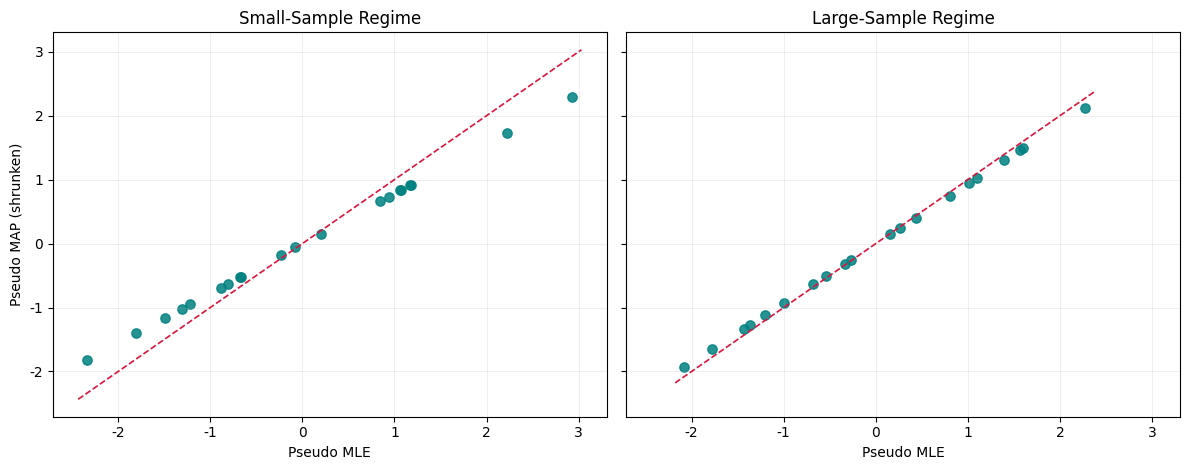

[해석] 소표본에서는 MAP 수축(shrinkage)이 상대적으로 크게 나타나며, 극단값 해석에 보수성이 필요하다.
[해석] 따라서 MAP 단독 보고보다 불확실성 지표(credible interval)와 함께 제시하는 것이 학술적으로 타당하다.


In [69]:
# [6-7 Simulation] 주의사항(caveats): 점추정 한계, shrinkage, 표본크기 효과를 시뮬레이션으로 확인.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(6107)
true_b = np.linspace(-2, 2, 20)

# 소표본 상황: 추정 노이즈가 큼
mle_small = true_b + rng.normal(0, 0.45, size=true_b.size)
map_small = 0.78 * mle_small  # prior 중심(0)으로의 수축(shrinkage) 가정

# 대표본 상황: 노이즈가 작음
mle_large = true_b + rng.normal(0, 0.15, size=true_b.size)
map_large = 0.93 * mle_large

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True)

for ax, x, y, title in [
    (axes[0], mle_small, map_small, 'Small-Sample Regime'),
    (axes[1], mle_large, map_large, 'Large-Sample Regime'),
]:
    ax.scatter(x, y, s=45, alpha=0.85, color='teal')
    lo = min(x.min(), y.min()) - 0.1
    hi = max(x.max(), y.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], '--', color='crimson', lw=1.2)
    ax.set_title(title)
    ax.set_xlabel('Pseudo MLE')
    ax.grid(alpha=0.2)

axes[0].set_ylabel('Pseudo MAP (shrunken)')
plt.tight_layout()
plt.show()

print('[해석] 소표본에서는 MAP 수축(shrinkage)이 상대적으로 크게 나타나며, 극단값 해석에 보수성이 필요하다.')
print('[해석] 따라서 MAP 단독 보고보다 불확실성 지표(credible interval)와 함께 제시하는 것이 학술적으로 타당하다.')

### 6-8. DIF 설명 (Differential Item Functioning)

**DIF (Differential Item Functioning)** 는 서로 다른 집단(group)이 **동일한 잠재능력(latent ability)** 수준을 가지고 있음에도 불구하고, 특정 문항에 대해 **상이한 정답확률(response probability)** 을 보이는 현상을 의미합니다.

즉, DIF의 핵심은 다음과 같습니다.
- 단순한 집단 평균 차이(mean difference)가 아니라,
- **능력을 통제(control for ability)** 한 이후에도 문항 반응이 집단에 따라 체계적으로 달라지는가를 묻는 것입니다.

예를 들어,
- 남학생과 여학생이 동일한 $\theta$ 수준을 가졌는데,
- 어떤 문항에서 한 집단이 일관되게 더 높은 정답확률을 보인다면,
그 문항은 DIF 가능성이 있다고 해석할 수 있습니다.

#### 왜 중요한가? (Why DIF matters)
DIF는 검사의 **공정성(fairness)** 과 **측정 불변성(measurement invariance)** 문제와 직접적으로 연결됩니다.

Rasch 모형은 원칙적으로 문항난이도 $b_i$가 집단에 무관하게 일정하다고 가정합니다. 따라서 DIF가 존재한다는 것은,
- 해당 문항이 Rasch의 불변성 가정을 위반하거나,
- 문항 내용이 특정 집단에 유리/불리하게 작동할 가능성이 있음을 시사합니다.

#### DIF의 대표적 유형 (Types of DIF)
1. **Uniform DIF**
- 전 능력구간 전반에서 한 집단이 지속적으로 더 유리하거나 불리한 경우
- 해석상 문항난이도(item difficulty)의 집단별 이동(shift)에 해당

2. **Non-uniform DIF**
- DIF의 방향이나 크기가 능력수준에 따라 달라지는 경우
- 이는 Rasch보다 2PL/interaction 구조에서 더 자주 논의되며, 문항의 변별도(discrimination) 차이나 상호작용(interaction)과 관련될 수 있습니다.

#### Rasch 맥락에서의 직관적 해석
Rasch 관점에서는 DIF를 다음처럼 이해할 수 있습니다.

- 기준집단(reference group)의 문항난이도: $b_i^{(R)}$
- 초점집단(focal group)의 문항난이도: $b_i^{(F)}$

만약
$$
        \Delta_i = b_i^{(F)} - b_i^{(R)}
$$
가 충분히 크다면, 해당 문항은 집단 간에 다른 난이도로 작동한다고 해석할 수 있습니다.

- $\Delta_i > 0$: focal group에서 더 어려운 문항
- $\Delta_i < 0$: focal group에서 더 쉬운 문항

#### DIF 분석의 목적
DIF 분석은 단순히 "문제가 있다"를 선언하기 위한 절차가 아니라, 다음을 위한 진단 도구(diagnostic tool)입니다.

1. 공정성 점검(fairness evaluation)
- 문항이 특정 집단에 체계적으로 편향되어 있는지 확인

2. 문항 개선(item revision)
- 표현, 맥락, 문화적 배경, 언어적 요구가 특정 집단에 불리하게 작용하는지 검토

3. 척도 타당화(scale validation)
- 검사가 집단 간 비교에 적합한지 검증

4. 후속 모형 확장(model extension)
- 필요 시 multi-group Rasch, DIF parameter model, explanatory IRT 등으로 확장

5. 응답자 그룹의 배경 연구
   
#### 실무적 주의사항
DIF가 발견되었다고 해서 곧바로 문항이 "나쁜 문항"이라는 뜻은 아닙니다.

해석 시에는 다음을 함께 고려해야 합니다.
- 효과크기(effect size)
- 표본크기(sample size)
- 집단 정의(group definition)의 타당성
- 내용전문가(content expert)의 문항 검토
- 통계적 유의성과 실제적 중요성(practical significance)의 구분

#### 요약
DIF는 **동일 능력 조건하에서 문항이 집단별로 다르게 기능하는 현상**이며, Rasch 분석에서 이는 측정의 공정성과 불변성을 점검하는 핵심 주제입니다.

따라서 DIF 분석은
- 집단 비교의 정당성 확보,
- 편향 문항 탐지,
- 검사 개선,
- 이론적 타당화
를 위해 반드시 검토할 가치가 있는 절차입니다.

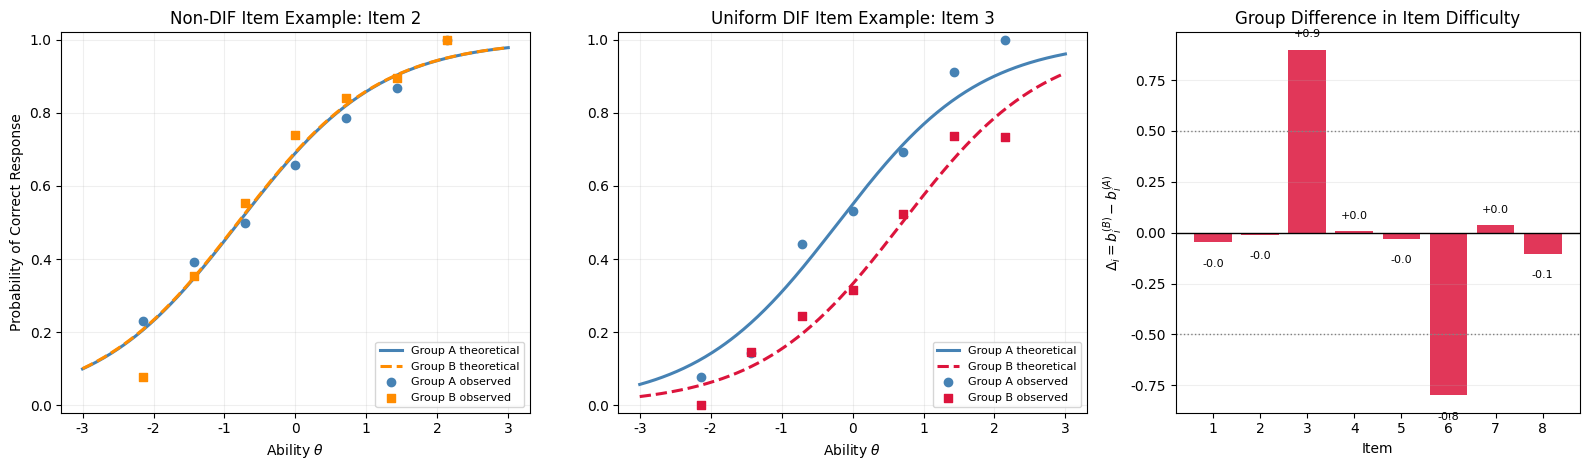

[해석] 왼쪽 패널의 점(marker)은 능력 구간(bin)별 관측 정답률(empirical proportion correct)이며, 원은 Group A, 사각형은 Group B를 의미한다.
[해석] Item 2는 두 집단의 이론곡선과 관측 정답률이 거의 겹치므로 DIF가 없는 문항(non-DIF item)의 전형적 예시로 볼 수 있다.
[해석] Item 3는 동일 능력 수준에서도 Group B의 정답확률 곡선이 우측으로 이동하므로, Group B에 더 어려운 uniform DIF 문항으로 해석된다.
[해석] 오른쪽 패널의 Δ_i가 0에서 멀수록 집단 간 난이도 이동(difficulty shift)이 크며, DIF 의심 근거가 강화된다.


In [ ]:
# [6-8 Simulation] 두 집단에서 DIF가 없는 문항과 있는 문항을 시뮬레이션하고 시각적으로 비교한다.

# [6-8 Simulation] 동일 능력 조건에서 집단별 정답확률 차이와 문항별 difficulty shift를 함께 확인한다.

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(6108)

# 두 집단은 동일한 능력분포를 갖도록 설정
n_per_group = 450
theta_group_a = rng.normal(0.0, 1.0, n_per_group)
theta_group_b = rng.normal(0.0, 1.0, n_per_group)
theta_all = np.concatenate([theta_group_a, theta_group_b])
group = np.array(['Group A'] * n_per_group + ['Group B'] * n_per_group)

# 기준 문항난이도와 DIF 설정
n_items = 8
b_base = np.array([-1.4, -0.8, -0.2, 0.3, 0.8, 1.2, -0.5, 0.5])
dif_shift = np.random.normal(0, 0.05, n_items)  # DIF가 없는 문항은 shift가 0에 가까움, 약간의 변동이 있을 수 있음.
dif_shift[2] = 0.9   # Item 3: Group B에서 더 어려움
dif_shift[5] = -0.8  # Item 6: Group B에서 더 쉬움
b_group_a = b_base.copy()
b_group_b = b_base + dif_shift

def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

def simulate_group_responses(theta, b_vec):
    prob = logistic(theta[:, None] - b_vec[None, :])
    y = rng.binomial(1, prob)
    return prob, y

p_a, y_a = simulate_group_responses(theta_group_a, b_group_a)
p_b, y_b = simulate_group_responses(theta_group_b, b_group_b)

# 능력 구간별 관측 정답률을 계산하여 ICC 형태로 비교
bin_edges = np.linspace(-2.5, 2.5, 8)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

def binned_accuracy(theta, y_item, edges):
    values = []
    for left, right in zip(edges[:-1], edges[1:]):
        mask = (theta >= left) & (theta < right)
        if mask.sum() >= 8:
            values.append(y_item[mask].mean())
        else:
            values.append(np.nan)
    return np.array(values)

item_no_dif = 1  # Item 2
item_dif = 2     # Item 3

obs_a_no_dif = binned_accuracy(theta_group_a, y_a[:, item_no_dif], bin_edges)
obs_b_no_dif = binned_accuracy(theta_group_b, y_b[:, item_no_dif], bin_edges)
obs_a_dif = binned_accuracy(theta_group_a, y_a[:, item_dif], bin_edges)
obs_b_dif = binned_accuracy(theta_group_b, y_b[:, item_dif], bin_edges)

theta_grid = np.linspace(-3, 3, 300)
curve_a_no_dif = logistic(theta_grid - b_group_a[item_no_dif])  # Item 2 번에 대한 문항 응답 곡선
curve_b_no_dif = logistic(theta_grid - b_group_b[item_no_dif])
curve_a_dif = logistic(theta_grid - b_group_a[item_dif]) # Item 3 번에 대한 문항 응답 곡선
curve_b_dif = logistic(theta_grid - b_group_b[item_dif])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), gridspec_kw={'width_ratios': [1.1, 1.1, 0.95]})

# 비-DIF 문항 비교
axes[0].plot(theta_grid, curve_a_no_dif, color='steelblue', lw=2.2, label='Group A theoretical')
axes[0].plot(theta_grid, curve_b_no_dif, color='darkorange', lw=2.2, linestyle='--', label='Group B theoretical')
axes[0].scatter(bin_centers, obs_a_no_dif, color='steelblue', s=36, zorder=3, label='Group A observed')
axes[0].scatter(bin_centers, obs_b_no_dif, color='darkorange', s=36, marker='s', zorder=3, label='Group B observed')
axes[0].set_title('Non-DIF Item Example: Item 2')
axes[0].set_xlabel('Ability $\\theta$')
axes[0].set_ylabel('Probability of Correct Response')
axes[0].set_ylim(-0.02, 1.02)
axes[0].grid(alpha=0.2)
axes[0].legend(loc='lower right', fontsize=8)

# DIF 문항 비교
axes[1].plot(theta_grid, curve_a_dif, color='steelblue', lw=2.2, label='Group A theoretical')
axes[1].plot(theta_grid, curve_b_dif, color='crimson', lw=2.2, linestyle='--', label='Group B theoretical')
axes[1].scatter(bin_centers, obs_a_dif, color='steelblue', s=36, zorder=3, label='Group A observed')
axes[1].scatter(bin_centers, obs_b_dif, color='crimson', s=36, marker='s', zorder=3, label='Group B observed')
axes[1].set_title('Uniform DIF Item Example: Item 3')
axes[1].set_xlabel('Ability $\\theta$')
axes[1].set_ylim(-0.02, 1.02)
axes[1].grid(alpha=0.2)
axes[1].legend(loc='lower right', fontsize=8)

# 문항별 집단 난이도 차이 요약
delta_b = b_group_b - b_group_a
bar_colors = np.where(np.abs(delta_b) > 1e-12, 'crimson', 'lightgray')
axes[2].bar(np.arange(1, n_items + 1), delta_b, color=bar_colors, alpha=0.85)
axes[2].axhline(0, color='black', lw=1)
axes[2].axhline(0.5, color='gray', linestyle=':', lw=1)
axes[2].axhline(-0.5, color='gray', linestyle=':', lw=1)
axes[2].set_title('Group Difference in Item Difficulty')
axes[2].set_xlabel('Item')
axes[2].set_ylabel(r'$\Delta_i = b_i^{(B)} - b_i^{(A)}$')
axes[2].set_xticks(np.arange(1, n_items + 1))
axes[2].grid(axis='y', alpha=0.2)
for idx, val in enumerate(delta_b, start=1):
    axes[2].text(idx, val + (0.05 if val >= 0 else -0.08), f'{val:+.1f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()
# ----------------------

print('[해석] 왼쪽 패널의 점(marker)은 능력 구간(bin)별 관측 정답률(empirical proportion correct)이며, 원은 Group A, 사각형은 Group B를 의미한다.')
print('[해석] Item 2는 두 집단의 이론곡선과 관측 정답률이 거의 겹치므로 DIF가 없는 문항(non-DIF item)의 전형적 예시로 볼 수 있다.')
print('[해석] Item 3는 동일 능력 수준에서도 Group B의 정답확률 곡선이 우측으로 이동하므로, Group B에 더 어려운 uniform DIF 문항으로 해석된다.')
print('[해석] 오른쪽 패널의 Δ_i가 0에서 멀수록 집단 간 난이도 이동(difficulty shift)이 크며, DIF 의심 근거가 강화된다.')


17:12:32 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\AppData\Local\Temp\tmp4xc2r5go\rasch_dif.stan to exe file C:\Users\yongduek\AppData\Local\Temp\tmp4xc2r5go\rasch_dif.exe
17:12:46 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\AppData\Local\Temp\tmp4xc2r5go\rasch_dif.exe
17:12:46 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

17:13:23 - cmdstanpy - INFO - CmdStan done processing.



DIF detection summary (96% credible interval):
  Item   gamma_mean         2%        98%     Flag
     1       -0.100     -0.476      0.241   No-DIF
     2       -0.211     -0.554      0.134   No-DIF
     3        0.756      0.445      1.067      DIF
     4        0.067     -0.266      0.380   No-DIF
     5       -0.094     -0.434      0.209   No-DIF
     6       -0.808     -1.137     -0.478      DIF
     7        0.123     -0.205      0.435   No-DIF
     8        0.112     -0.203      0.430   No-DIF


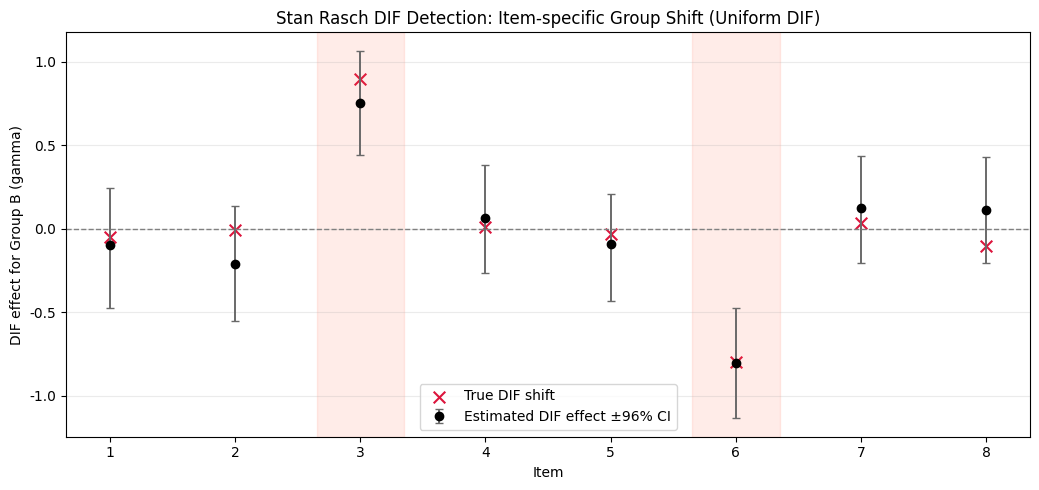


[해석] 96% 신용구간이 0을 포함하지 않는 문항을 DIF 의심 문항으로 판정했다.
[해석] 탐지된 DIF 문항(1-based): [3, 6]
[해석] 시뮬레이션에서 실제로 큰 DIF를 부여한 문항(기준 |shift|>=0.4): [3, 6]


In [77]:

import os, tempfile
import numpy as np
import matplotlib.pyplot as plt
import cmdstanpy

# Build combined response matrix: Group A (g=0), Group B (g=1)
if 'y_a' not in globals() or 'y_b' not in globals():
    raise ValueError('Run the DIF simulation cell first so that y_a and y_b are available.')

Y_dif = np.vstack([y_a, y_b]).astype(int)
J_total = Y_dif.shape[0]
I_total = Y_dif.shape[1]
g_person = np.concatenate([np.zeros(y_a.shape[0], dtype=int),
                            np.ones(y_b.shape[0], dtype=int)])

# Long-format arrays for Stan
jj, ii, g_obs, y_obs = [], [], [], []
for j in range(J_total):
    for i in range(I_total):
        jj.append(j + 1)
        ii.append(i + 1)
        g_obs.append(int(g_person[j]))
        y_obs.append(int(Y_dif[j, i]))

stan_code_dif = """
data {
  int<lower=1> J;                        // persons
  int<lower=1> I;                        // items
  int<lower=1> N;                        // observations
  array[N] int<lower=1,upper=J> jj;      // person index
  array[N] int<lower=1,upper=I> ii;      // item index
  array[N] int<lower=0,upper=1> g;       // group indicator (0=A, 1=B)
  array[N] int<lower=0,upper=1> y;       // response
}
parameters {
  vector[J] theta;                       // person ability
  vector[I] b;                           // baseline item difficulty (Group A)
  vector[I] gamma;                       // DIF shift for Group B (uniform DIF)
}
model {
  theta ~ normal(0, 1);
  b     ~ normal(0, 2);
  gamma ~ normal(0, 0.5);
  for (n in 1:N)
    y[n] ~ bernoulli_logit(theta[jj[n]] - (b[ii[n]] + g[n] * gamma[ii[n]]));
}
"""

stan_data_dif = {
    'J': int(J_total), 'I': int(I_total), 'N': int(J_total * I_total),
    'jj': jj, 'ii': ii, 'g': g_obs, 'y': y_obs,
}

tmpdir_dif = tempfile.mkdtemp()
stan_path_dif = os.path.join(tmpdir_dif, 'rasch_dif.stan')
with open(stan_path_dif, 'w', encoding='utf-8') as f:
    f.write(stan_code_dif)

model_dif = cmdstanpy.CmdStanModel(stan_file=stan_path_dif)
fit_dif = model_dif.sample(data=stan_data_dif, chains=4,
                           iter_warmup=500, iter_sampling=500,
                           seed=5108, show_progress=True)

gamma_post = fit_dif.stan_variable('gamma')   # shape: (draws, I_total)
gamma_mean = gamma_post.mean(axis=0)
gamma_low, gamma_high = np.quantile(gamma_post, [0.02, 0.98], axis=0)
dif_flag = (gamma_low > 0) | (gamma_high < 0)

print('DIF detection summary (96% credible interval):')
print(f"{'Item':>6} {'gamma_mean':>12} {'2%':>10} {'98%':>10} {'Flag':>8}")
for i in range(I_total):
    flag_txt = 'DIF' if dif_flag[i] else 'No-DIF'
    print(f"{i+1:>6} {gamma_mean[i]:>12.3f} {gamma_low[i]:>10.3f} {gamma_high[i]:>10.3f} {flag_txt:>8}")

# Visualization: posterior DIF effect with 96% credible intervals
x = np.arange(1, I_total + 1)
fig, ax = plt.subplots(figsize=(10.5, 5.0))
ax.errorbar(x, gamma_mean,
            yerr=[gamma_mean - gamma_low, gamma_high - gamma_mean],
            fmt='o', color='black', ecolor='dimgray',
            elinewidth=1.4, capsize=3,
            label='Estimated DIF effect ±96% CI')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
if 'dif_shift' in globals() and len(dif_shift) == I_total:
    ax.scatter(x, dif_shift, color='crimson', marker='x', s=70, label='True DIF shift')
for xi, flag in zip(x, dif_flag):
    if flag:
        ax.axvspan(xi - 0.35, xi + 0.35, color='tomato', alpha=0.12)
ax.set_xticks(x)
ax.set_xlabel('Item')
ax.set_ylabel('DIF effect for Group B (gamma)')
ax.set_title('Stan Rasch DIF Detection: Item-specific Group Shift (Uniform DIF)')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

flag_items = [int(i + 1) for i in np.where(dif_flag)[0]]
print('\n[해석] 96% 신용구간이 0을 포함하지 않는 문항을 DIF 의심 문항으로 판정했다.')
print(f'[해석] 탐지된 DIF 문항(1-based): {flag_items}')
if 'dif_shift' in globals():
    true_major = [int(i + 1) for i in np.where(np.abs(dif_shift) >= 0.4)[0]]
    print(f'[해석] 시뮬레이션에서 실제로 큰 DIF를 부여한 문항(기준 |shift|>=0.4): {true_major}')


## Non-uniform DIF (비균일 DIF): 집단 × 능력 상호작용

### A. 개념

**Uniform DIF(균일 DIF)**는 집단 간 문항 난이도가 능력 수준에 관계없이 **일정하게** 이동하는 경우다.  
앞 셀의 Rasch+gamma 모형이 이에 해당한다.

**Non-uniform DIF(비균일 DIF)**는 집단 간 차이가 능력 수준에 따라 **달라지는** 경우다.  
즉, 어떤 문항이 낮은 능력 구간에서는 집단 A에게 유리하고, 높은 능력 구간에서는 집단 B에게 유리할 수 있다.  
이는 두 집단의 ICC가 서로 **교차(crossing)**하거나 기울기가 다를 때 나타난다.

$$P(Y=1 \mid \theta, g) = \text{logistic}\bigl(a_i(\theta - b_i) - g \cdot [\gamma_i + \delta_i \cdot \theta]\bigr)$$

| 파라미터 | 의미 | DIF 유형 |
|---|---|---|
| $\gamma_i$ | 집단 간 절편 이동 (난이도 shift) | Uniform DIF |
| $\delta_i$ | 집단 × 능력 상호작용 | **Non-uniform DIF** |

- $\delta_i = 0$, $\gamma_i \ne 0$ → Uniform DIF
- $\delta_i \ne 0$ → Non-uniform DIF (ICC 교차 가능)
- ICC가 교차하면 단순 난이도 비교만으로는 탐지 불가

### B. 수학적 본질
**Rasch(1PL) 모델의 구조적 제약**

- Rasch 모델의 ICC는 모든 문항의 변별도(discrimination)가 1로 고정된다:

$$P(Y=1|\theta) = \text{logistic}(\theta - b_i)$$

- 기울기가 모두 동일하므로, 두 집단의 ICC는 절편(난이도)만 이동할 수 있고 **절대 교차(cross)하지 않는다**. 즉 Rasch 모델 안에서는 구조적으로 **Uniform DIF만 존재 가능**하다.

**Non-uniform DIF의 수학적 본질**

- 위 Non-uniform DIF의 수학 모형을 전개하면 아래와 같이 바꿀 수 있다.

$$P(Y=1|\theta, g=1) = \text{logistic}\bigl((1-\delta_i)\,\theta - (b_i + \gamma_i)\bigr)$$

- 이는 Group B의 실효 변별도가 $(1-\delta_i)$, 실효 난이도가 $\frac{b_i+\gamma_i}{1-\delta_i}$ 인 **2PL 문항**과 동일하다. 즉  `delta_i * theta` 항이 결국 변별도 차이를 만들어낸다.
$$
    a_i' = 1-\delta_i \quad,\quad\quad\quad
    b_i' = \frac{b_i+\gamma_i}{1-\delta_i}
$$

**결론**

| 모델 | 가능한 DIF 유형 |
|---|---|
| Rasch (1PL) | Uniform DIF만 가능 |
| 2PL 이상 | Uniform + **Non-uniform DIF** 모두 가능 |

따라서 앞 셀(Cell 42)에서 구현한 Stan 모형은 이름은 "Rasch 확장"이지만, `delta` 파라미터가 Group B의 변별도를 변화시키므로 실질적으로 **2PL 기반 모형**이다. 순수 Rasch 제약(모든 문항/집단의 변별도 = 1) 하에서 Non-uniform DIF를 탐지하는 것은 불가능하다.

### C. Stan 모형

아래 셀은 **Non-uniform DIF 모형**을 Stan으로 구현한다.

- `gamma[i]`: 집단 B의 절편 이동 (uniform DIF 성분)
- `delta[i]`: 집단 B의 $\theta \times$ 집단 상호작용 (non-uniform DIF 성분)
- 탐지 기준: `delta[i]`의 96% 신용구간이 0을 포함하지 않으면 **Non-uniform DIF** 판정


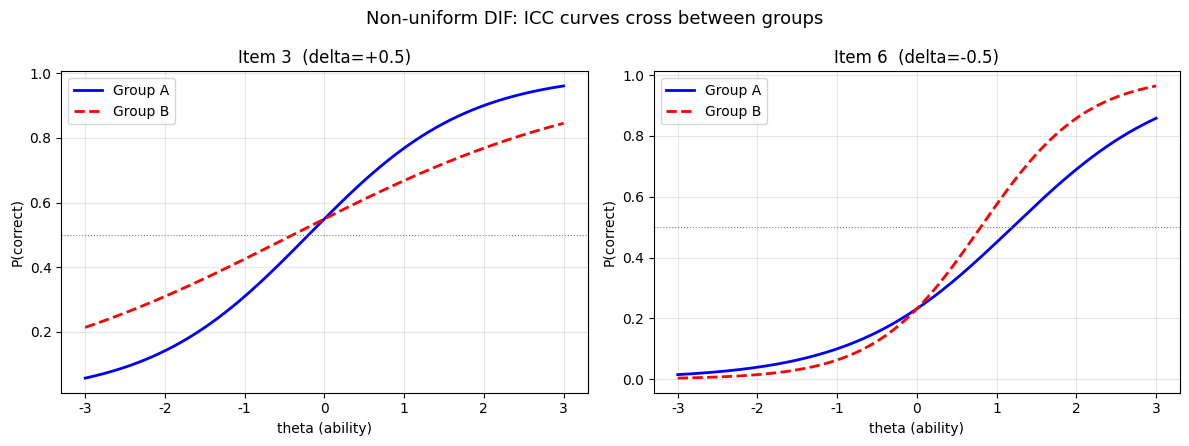

17:45:45 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\AppData\Local\Temp\tmpebn88kc7\rasch_nudif.stan to exe file C:\Users\yongduek\AppData\Local\Temp\tmpebn88kc7\rasch_nudif.exe


[해석] Non-uniform DIF가 있을 때 두 집단의 ICC는 능력 수준에 따라 교차한다.
[해석] 낮은 theta에서 A가 유리하던 문항이 높은 theta에서는 B가 유리해질 수 있다.


17:45:58 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\AppData\Local\Temp\tmpebn88kc7\rasch_nudif.exe
17:45:59 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

17:46:41 - cmdstanpy - INFO - CmdStan done processing.




Non-uniform DIF detection summary (96% CI for delta):
  Item   true_delta   delta_mean         2%        98%         Flag
     1        0.000        0.038     -0.307      0.376       No-DIF
     2        0.000       -0.014     -0.361      0.306       No-DIF
     3        0.500        0.399      0.120      0.663 Non-unif DIF
     4        0.000       -0.078     -0.418      0.241       No-DIF
     5        0.000       -0.132     -0.493      0.214       No-DIF
     6       -0.500       -0.119     -0.465      0.218       No-DIF
     7        0.000        0.122     -0.211      0.450       No-DIF
     8        0.000       -0.138     -0.522      0.183       No-DIF


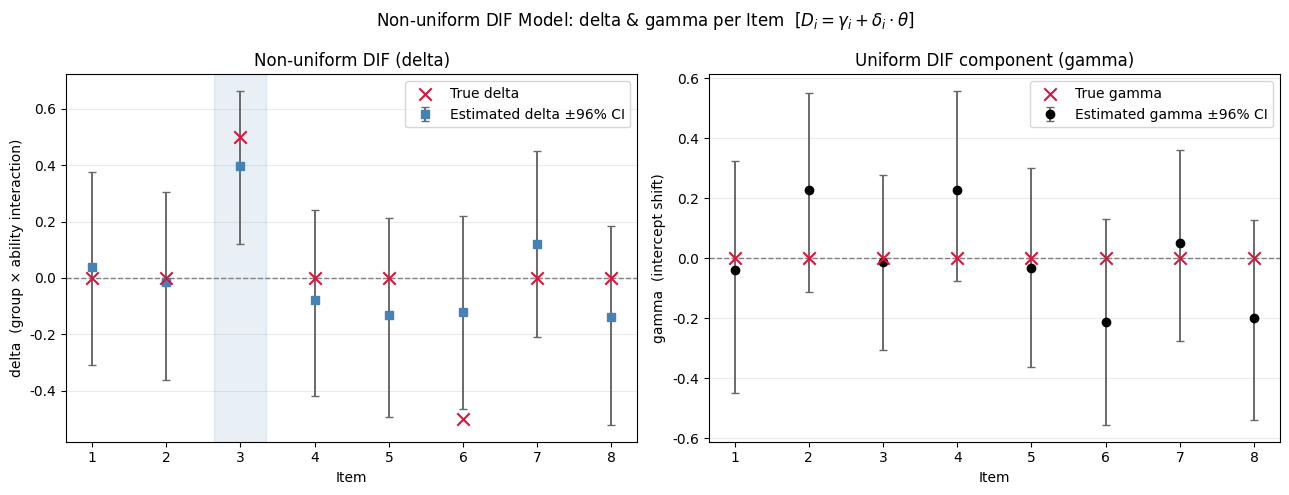


[해석] 96% 신용구간이 0을 포함하지 않는 delta를 가진 문항을 Non-uniform DIF로 판정했다.
[해석] 탐지된 Non-uniform DIF 문항: [3]
[해석] 시뮬레이션에서 delta를 부여한 문항(|delta|>=0.3): [3, 6]
[해석] theta를 Stan parameter로 포함하여 완전한 베이지안 동시 추정을 수행했다.
[해석] 이 방식은 theta 추정의 불확실성을 DIF 파라미터 추정에 올바르게 전파한다.


In [83]:

import os, tempfile
import numpy as np
import matplotlib.pyplot as plt
import cmdstanpy

# ── Simulation ─────────────────────────────────────────────────────────────
rng_nu = np.random.default_rng(2026)
n_per_group_nu = 450
n_items_nu = 8
theta_a_nu = rng_nu.normal(0, 1, n_per_group_nu)
theta_b_nu = rng_nu.normal(0, 1, n_per_group_nu)
b_nu       = np.array([-1.4, -0.8, -0.2, 0.3, 0.8, 1.2, -0.5, 0.5])
gamma_nu   = np.zeros(n_items_nu)     # true uniform DIF (all zero in this simulation)
delta_true = np.zeros(n_items_nu)
delta_true[2] =  0.5                  # Item 3: non-uniform DIF
delta_true[5] = -0.5                  # Item 6: non-uniform DIF

def sim_responses_nu(theta, b, gamma_shift, delta_shift, g_val, rng):
    n, m = len(theta), len(b)
    y = np.zeros((n, m), dtype=int)
    for i in range(m):
        logit = theta - b[i] - g_val * (gamma_shift[i] + delta_shift[i] * theta)
        p = 1 / (1 + np.exp(-logit))
        y[:, i] = (rng.uniform(size=n) < p).astype(int)
    return y

y_a_nu = sim_responses_nu(theta_a_nu, b_nu, gamma_nu, delta_true, g_val=0, rng=rng_nu)
y_b_nu = sim_responses_nu(theta_b_nu, b_nu, gamma_nu, delta_true, g_val=1, rng=rng_nu)

# ── ICC crossing plot ───────────────────────────────────────────────────────
theta_grid = np.linspace(-3, 3, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, item_idx, ttl in zip(axes, [2, 5],
                              ['Item 3  (delta=+0.5)', 'Item 6  (delta=-0.5)']):
    p_a_nu = 1 / (1 + np.exp(-(theta_grid - b_nu[item_idx])))
    p_b_nu = 1 / (1 + np.exp(-(theta_grid - b_nu[item_idx]
                                - (gamma_nu[item_idx] + delta_true[item_idx] * theta_grid))))
    ax.plot(theta_grid, p_a_nu, 'b-',  lw=2, label='Group A')
    ax.plot(theta_grid, p_b_nu, 'r--', lw=2, label='Group B')
    ax.axhline(0.5, color='gray', lw=0.8, linestyle=':')
    ax.set_xlabel('theta (ability)'); ax.set_ylabel('P(correct)')
    ax.set_title(ttl); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Non-uniform DIF: ICC curves cross between groups', fontsize=13)
plt.tight_layout(); plt.show()

print('[해석] Non-uniform DIF가 있을 때 두 집단의 ICC는 능력 수준에 따라 교차한다.')
print('[해석] 낮은 theta에서 A가 유리하던 문항이 높은 theta에서는 B가 유리해질 수 있다.')

# ── Long-format Stan data ───────────────────────────────────────────────────
Y_nu  = np.vstack([y_a_nu, y_b_nu]).astype(int)
J_nu  = Y_nu.shape[0]
I_nu  = Y_nu.shape[1]
g_nu  = np.concatenate([np.zeros(n_per_group_nu, dtype=int),
                         np.ones(n_per_group_nu, dtype=int)])

jj_nu, ii_nu, g_obs_nu, y_obs_nu = [], [], [], []
for j in range(J_nu):
    for i in range(I_nu):
        jj_nu.append(j + 1); ii_nu.append(i + 1)
        g_obs_nu.append(int(g_nu[j])); y_obs_nu.append(int(Y_nu[j, i]))

# ── Stan model: theta is a latent parameter (fully joint Bayesian estimation) ──
# NOTE: theta는 데이터가 아닌 파라미터로 정의한다.
# theta_hat을 고정값으로 쓰면 theta 추정 불확실성이 무시되어 DIF 추정이 편향될 수 있다.
# 완전한 베이지안 접근에서는 theta, b, gamma, delta를 동시에 추정한다.
stan_code_nudif = """
data {
  int<lower=1> J;
  int<lower=1> I;
  int<lower=1> N;
  array[N] int<lower=1,upper=J> jj;
  array[N] int<lower=1,upper=I> ii;
  array[N] int<lower=0,upper=1> g;
  array[N] int<lower=0,upper=1> y;
}
parameters {
  vector[J] theta;              // person ability  (latent, jointly estimated)
  vector[I] b;                  // item difficulty baseline (Group A)
  vector[I] gamma;              // uniform DIF shift (intercept)
  vector[I] delta;              // non-uniform DIF: group x ability interaction
}
model {
  theta ~ normal(0, 1);         // population prior (scale identification)
  b     ~ normal(0, 2);
  gamma ~ normal(0, 0.5);
  delta ~ normal(0, 0.3);
  for (n in 1:N)
    y[n] ~ bernoulli_logit(theta[jj[n]] - b[ii[n]]
                           - g[n] * (gamma[ii[n]] + delta[ii[n]] * theta[jj[n]]));
}
"""

stan_data_nudif = {
    'J': int(J_nu), 'I': int(I_nu), 'N': int(J_nu * I_nu),
    'jj': jj_nu, 'ii': ii_nu, 'g': g_obs_nu, 'y': y_obs_nu,
}

tmpdir_nu    = tempfile.mkdtemp()
stan_path_nu = os.path.join(tmpdir_nu, 'rasch_nudif.stan')
with open(stan_path_nu, 'w', encoding='utf-8') as f:
    f.write(stan_code_nudif)

model_nu = cmdstanpy.CmdStanModel(stan_file=stan_path_nu)
fit_nu   = model_nu.sample(data=stan_data_nudif, chains=4,
                            iter_warmup=500, iter_sampling=500,
                            seed=5108, show_progress=True)

# ── Posterior summaries ─────────────────────────────────────────────────────
delta_post   = fit_nu.stan_variable('delta')
delta_mean   = delta_post.mean(axis=0)
delta_low, delta_high = np.quantile(delta_post, [0.02, 0.98], axis=0)
nudif_flag   = (delta_low > 0) | (delta_high < 0)

gamma_post_nu  = fit_nu.stan_variable('gamma')
gamma_mean_nu  = gamma_post_nu.mean(axis=0)
gamma_low_nu, gamma_high_nu = np.quantile(gamma_post_nu, [0.02, 0.98], axis=0)
udif_flag      = (gamma_low_nu > 0) | (gamma_high_nu < 0)

print('\nNon-uniform DIF detection summary (96% CI for delta):')
print(f"{'Item':>6} {'true_delta':>12} {'delta_mean':>12} {'2%':>10} {'98%':>10} {'Flag':>12}")
for i in range(I_nu):
    flag_txt = 'Non-unif DIF' if nudif_flag[i] else 'No-DIF'
    print(f"{i+1:>6} {delta_true[i]:>12.3f} {delta_mean[i]:>12.3f} "
          f"{delta_low[i]:>10.3f} {delta_high[i]:>10.3f} {flag_txt:>12}")

# ── Visualization ───────────────────────────────────────────────────────────
x = np.arange(1, I_nu + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax0 = axes[0]
ax0.errorbar(x, delta_mean,
             yerr=[delta_mean - delta_low, delta_high - delta_mean],
             fmt='s', color='steelblue', ecolor='dimgray',
             elinewidth=1.4, capsize=3, label='Estimated delta ±96% CI')
ax0.axhline(0, color='gray', linestyle='--', lw=1)
ax0.scatter(x, delta_true, color='crimson', marker='x', s=80, zorder=5, label='True delta')
for xi, flag in zip(x, nudif_flag):
    if flag:
        ax0.axvspan(xi - 0.35, xi + 0.35, color='steelblue', alpha=0.12)
ax0.set_xticks(x); ax0.set_xlabel('Item')
ax0.set_ylabel('delta  (group × ability interaction)')
ax0.set_title('Non-uniform DIF (delta)'); ax0.grid(axis='y', alpha=0.25)
ax0.legend(loc='best')

ax1 = axes[1]
ax1.errorbar(x, gamma_mean_nu,
             yerr=[gamma_mean_nu - gamma_low_nu, gamma_high_nu - gamma_mean_nu],
             fmt='o', color='black', ecolor='dimgray',
             elinewidth=1.4, capsize=3, label='Estimated gamma ±96% CI')
ax1.axhline(0, color='gray', linestyle='--', lw=1)
ax1.scatter(x, gamma_nu, color='crimson', marker='x', s=80, zorder=5, label='True gamma')
for xi, flag in zip(x, udif_flag):
    if flag:
        ax1.axvspan(xi - 0.35, xi + 0.35, color='tomato', alpha=0.12)
ax1.set_xticks(x); ax1.set_xlabel('Item')
ax1.set_ylabel('gamma  (intercept shift)')
ax1.set_title('Uniform DIF component (gamma)'); ax1.grid(axis='y', alpha=0.25)
ax1.legend(loc='best')

plt.suptitle('Non-uniform DIF Model: delta & gamma per Item  '
             r'[$D_i = \gamma_i + \delta_i \cdot \theta$]', fontsize=12)
plt.tight_layout(); plt.show()

nudif_items = [int(i + 1) for i in np.where(nudif_flag)[0]]
true_nudif  = [int(i + 1) for i in np.where(np.abs(delta_true) >= 0.3)[0]]
print(f'\n[해석] 96% 신용구간이 0을 포함하지 않는 delta를 가진 문항을 Non-uniform DIF로 판정했다.')
print(f'[해석] 탐지된 Non-uniform DIF 문항: {nudif_items}')
print(f'[해석] 시뮬레이션에서 delta를 부여한 문항(|delta|>=0.3): {true_nudif}')
print('[해석] theta를 Stan parameter로 포함하여 완전한 베이지안 동시 추정을 수행했다.')
print('[해석] 이 방식은 theta 추정의 불확실성을 DIF 파라미터 추정에 올바르게 전파한다.')


Item 3(true delta=+0.5)은 여전히 탐지되고, Item 6(true delta=-0.5)는 delta_mean=-0.12로 추정되어 미탐지된다. 이는 Item 6이 매우 어려운 문항(b=1.2)이라 대부분 피험자의 반응 정보가 적은 theta 구간에 집중되는 검증력(power) 부족 문제다.

## 차별문항기능(DIF)의 정성적 해석: 세대별 관점

> **참고**: Zumbo (2007), *Socioeconomic Status and the DIF Context*, 및 Penfield & Camilli (2007) 등의 문헌에 기반한 세대 구분이다.

---

### 1세대 DIF: 통계적 탐지 중심 (1970s–1980s)

**핵심 질문: "DIF가 존재하는가?"**

- 대표 방법: Mantel-Haenszel(MH), SIBTEST, Lord's χ²
- 능력 수준을 **총점**으로 통제한 뒤 집단 간 정답률 차이를 검정
- DIF가 탐지되면 해당 문항을 **수정 또는 제거**하는 것이 목적
- **한계**: "있다/없다"의 이분법적 결론만 가능; 왜 발생하는지 설명 불가
- 정성적 해석: **없음** — 순수 통계 절차

---

### 2세대 DIF: IRT 기반 측정 불변성 (1980s–1990s)

**핵심 질문: "능력을 통제한 후 순수한 집단 차이가 있는가?"**

- 대표 방법: IRT 로그 가능도 비검정(LRT), Raju의 부호 면적, Drasgow의 방법
- 총점 대신 **잠재 능력(θ)** 을 통제하여 보다 정확한 DIF 추정
- Uniform DIF(ICC 평행 이동)와 **Non-uniform DIF(ICC 교차)** 를 구분
- 문항이 특정 집단에게 일관되게 유리/불리한지를 ICC 비교로 시각화
- **한계**: DIF의 통계적 크기는 알지만, **인과 메커니즘은 여전히 설명 불가**
- 정성적 해석: "Group B에서 문항 3이 능력 대비 더 어렵다" — 방향과 크기 기술

---

### 3세대 DIF: 설명적·인과적 접근 (2000s~)

**핵심 질문: "무엇이 DIF를 유발하는가?"**

- 대표 방법: 다층 모형(HLM), 문항 반응 시간 모형, 설명적 IRT(LLTM), 인지진단 모형
- 문항의 언어적 복잡도, 문화적 편향, 그림 유무, 맥락 친숙도 등을 **예측 변수**로 모형에 포함
- DIF를 유발하는 **문항 특성(item attribute)** 또는 **피험자 맥락(context)** 을 규명
- 예: "영어 어휘 부담이 높은 문항은 이민자 집단에서 DIF를 보인다"
- **한계**: 맥락 변수 선정에 이론적 근거 필요; 인과 추론의 한계
- 정성적 해석: DIF의 **내용적 원인**을 분석가·내용 전문가가 함께 해석

---

### 4세대 DIF: 측정 공정성과 사회적 형평성 (2010s~)

**핵심 질문: "이 측정 도구는 모든 집단에게 공정한가?"**

- 대표 방법: 알고리즘 공정성(Fairness-aware ML), 베이지안 DIF, 딥러닝 기반 탐지
- DIF를 **검사 개발의 기술적 오류**가 아닌 **사회 구조적 불평등의 반영**으로 재해석
- 교육 측정을 넘어 의료 진단, 고용 선발, AI 의사결정 알고리즘에도 적용
- 단순 문항 제거 대신, 집단 간 경험·기회의 차이를 고려한 **검사 설계 개혁**을 지향
- 측정 불변성과 **측정 공정성(measurement fairness)** 을 구분: 통계적 동일성이 사회적 공정성을 보장하지 않음
- 정성적 해석: DIF 결과를 정책 결정자·피험자 집단과 **함께** 해석하는 참여적 접근

---

### 세대별 비교 요약

| | 1세대 | 2세대 | 3세대 | 4세대 |
|---|---|---|---|---|
| 핵심 질문 | DIF가 있는가? | 얼마나 크며 어떤 유형인가? | 왜 발생하는가? | 공정한가? |
| 이론적 기반 | CTT | IRT | 설명적 IRT, 인지 모형 | 공정성 이론, 사회 이론 |
| 능력 통제 | 총점 | 잠재 능력(θ) | 잠재 능력 + 맥락 | 잠재 능력 + 구조적 맥락 |
| 결과 활용 | 문항 제거 | ICC 수정/재보정 | 문항 개발 지침 | 검사 설계 및 정책 개혁 |
| 해석 주체 | 통계학자 | 측정 전문가 | 내용 전문가 협업 | 다학제·참여적 해석 |


End.